сразу извинение за не самые красивые рисунки...

In [2]:
import pandas as pd
import numpy as np
import scipy 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [81]:
df = pd.read_csv('ab_test_orders.csv', index_col = 0)

## **Часть 1. Выбор метрик и формулировка гипотез**

**<h3>1. основная метрика успеха (primacy metric)</h3>**

главная цель вводимой фичи - повышение среднего чека (GMV на заказ). Поэтому логично, что основной метрикой A/B теста будет именно ***средний чек (GMV на заказ)***

**<h3>2. защитная метрика (guardrail metric)</h3>**

защитной метрикой я выбрала ***среднюю маржинальную прибыль на заказ***. Когда речь идет о введении скидок, важно следить за маржинальной прибылью, ведь скидка уменьшает именно прибыль, а не себестоимость товара => повальные скидки приведут нас к понижению маржи. Ведь, может, все наши пользователи решат шикануть раз в месяц в дорогущем ресторане из подборки вместо каждодневного визита в макдональдс. GMV per order подскочит, а вот с маржой (скорее всего) проиграем...

**<h3>3. дополнительные диагностические метрики</h3>**

***частота заказов на пользователя*** - следует из цели запуска повысить вовлеченность пользователей. *участились ли заказы в среднем на пользователя?*

***количество новых пользователей*** - так как у нас данные уже о заказах, мы можем сравниь количество заказов от new users в обеих группах. небольшая проблема цели - хотят привлечь новых пользователей через промокоды именно, то есть предполагается, что новые пользователи будут им пользоваться? это уже тяжело проверить за один тест. *изменилось ли количество привлеченных впервые покупателей?*

**<h3>4. $H_0$ и $H_a$</h3>**

здесь выбираем между односторонней (те GMV per order увелится) и двусторонней (GMV per order изменится) альтернативой. я сходу, если честно, не могу придумать такого, чтобы скидка на первый заказ резко поднимала средний чек, наоборот, есть риск, что метрика уменьшится. поэтому я возьму двустороннюю альтернативу.

$\mu_c$ - mean GMV per order in control group

$\mu_t$ - mean GMV per order in test group

**$H_0$**: $\mu_c = \mu_t$

**$H_a$**: $\mu_c \neq \mu_t$ (двусторонняя альтернатива)

уровень значимости давайте выберем $\alpha = 0.05$: "золотой стандарт"; в данной задаче я не вижу каких-то супер критических факторов. ну окэй, примем **$H_0$** с $\mu_c = \mu_t$, ну и бог с ним. будет предложка.



немного о целях запуска.

"повысить вовлечённость: долю активных пользователей" и "привлечь новых пользователей к первому заказу через промокоды"

имеющейся у нас информации недостаточно для их исследования. 
Ведь наша таблица - это информация о заказах за период тестирования. ведь все пользователи, которые делают заказы, считаются активными, а информации о пользователях без заказов у нас нет. а про новичков? у нас есть `tenure_days` - время с регистрации до старта эксперимента. но минимальное количество дней до начала эксперимента = 1. а если в этот день уже были заказы?.. 

и вообще, в `tenure_days` творится что-то странное. есть огромный пик на `1000`. распределение этой величины одинаково для все групп пользователей в `user_segment`. возможно это что-то типа `nan`, но я не могу это утверждать. какой-то выброс, наврное :(

(0.0, 1049.95)

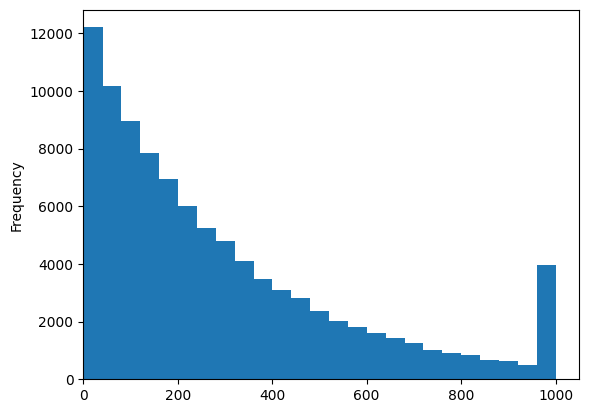

In [200]:
df[['user_id', 'tenure_days']].drop_duplicates().tenure_days.plot.hist(bins = 25)
plt.xlim(0)

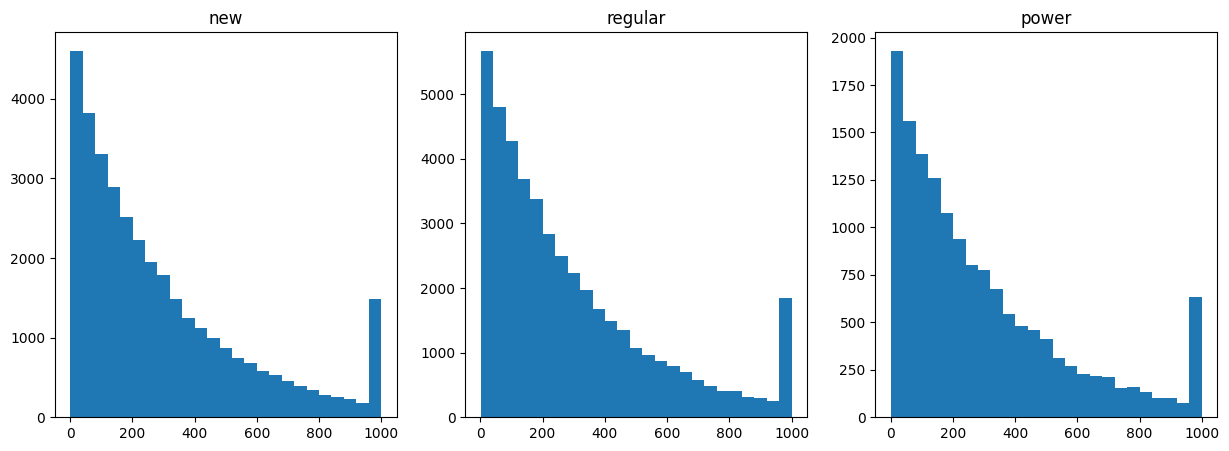

In [203]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

for i, user_segment in enumerate(df.user_segment.unique()):
    axes[i].hist(df[df['user_segment'] == user_segment][['user_id', 'tenure_days']].drop_duplicates().tenure_days, bins = 25)
    axes[i].set_title(user_segment)

## **Часть 2. Основной анализ**

In [5]:
class Bootstrap:
    def __init__(self, control, test, metric_name = 'средний чек (GMV per order)', B = 1e4):
        self.control = control
        self.n_control = len(control)
        self.mu_c = control.mean()
        self.test = test
        self.n_test = len(test)
        self.mu_t = test.mean()
        self.B = int(B)
        self.metric_name = metric_name
        self.lower_bound = self.upper_bound = None
        self.percent = None

        differences = []

        for i in range(self.B):
            control_curr_mean = np.random.choice(self.control, size=self.n_control, replace=True).mean()
            test_curr_mean = np.random.choice(self.test, size=self.n_test, replace=True).mean()

            differences.append(test_curr_mean - control_curr_mean)

        self.differences = np.array(sorted(differences))

    def get_stats(self):
        print(f'{self.metric_name}: ')
        print(f'    в контрольной группе: {self.mu_c:.3f}')
        print(f'    в тестовой группе: {self.mu_t:.3f}\n')


        # считаем разницу средних (абсолютная + относительная)
        print(f'разница средних:')
        print(f'    абсолютная: {self.mu_t - self.mu_c:.3f}')
        print(f'    относительная: {abs(self.mu_t - self.mu_c) / self.mu_c * 100:.2f}%\n')


    def draw_histogram(self, color = 'sandybrown'):
        figure, ax = plt.subplots(figsize = (10,8))
        ax.set_facecolor('snow')
        ax.hist(self.differences, bins = 50, color = color)
        ax.axvline(x = self.differences[self.lower_bound], ls = '--', lw = 3, color = 'black')
        ax.axvline(x = self.differences[self.upper_bound], ls = '--', lw = 3, color = 'black')
        ax.axvspan( self.differences.min(),  self.differences[self.lower_bound], color='snow', alpha = 0.5)
        ax.axvspan(self.differences[self.upper_bound],  self.differences.max(), color='snow', alpha = 0.5)
        plt.title(f'{int(self.percent*100)}% CI: {self.differences[self.lower_bound]:.2f} - {self.differences[self.upper_bound]:.2f} для {self.metric_name}', size = 16)
        plt.show()

    def CI(self, percent = 0.95, print_ci = True):
        self.percent = percent
        if self.percent > 1:
            self.percent = percent / 100
        self.lower_bound = int(self.B * (1 - self.percent) / 2)
        self.upper_bound = int(self.B * (1 - (1 - self.percent) / 2))

        if print_ci:
            print(f'мы на {int(percent*100)}% уверены, что (mu_t - mu_c) находится в интервале {self.differences[self.lower_bound]:.3f} and {self.differences[self.upper_bound]:.3f}\n')
            self.draw_histogram()

        return self.differences[self.lower_bound], self.differences[self.upper_bound]

    def pvalue(self, a = 0.05, both = False):
        ttest_pvalue = scipy.stats.ttest_ind(self.test, self.control, equal_var = False).pvalue

        if not both:
            if ttest_pvalue < a:
                return f't-test p-value is {ttest_pvalue:.4f}; reject H0'
            else:
                return f't-test p-value is {ttest_pvalue:.4f}; do not reject H0'
        
        
        # # есть возможность посчитать p-value по бутстрэпу, она встроена
        # https://web.stanford.edu/class/archive/cs/cs109/cs109.1218/files/student_drive/9.7.pdf
        # https://www.alexkaizer.com/bios_6618/files/bios6618/W16/bootstrap_pvalue.pdf

        common = np.hstack([self.control, self.test])
        null_differences = []
        for i in range(self.B):
            a_la_control_sample = np.random.choice(common, size=self.n_control, replace=True).mean()
            a_la_test_sample = np.random.choice(common, size=self.n_test, replace=True).mean()

            null_differences.append(a_la_test_sample - a_la_control_sample)

        null_differences = np.array(null_differences)

        bootstrap_pvalue = len(null_differences[(null_differences >= abs(self.mu_t - self.mu_c)) | (null_differences <= -abs(self.mu_t - self.mu_c))]) / self.B

        out = ''
        if ttest_pvalue < a:
            out += f't-test p-value is {ttest_pvalue:.4f}; reject H0\n'
        else:
            out += f't-test p-value is {ttest_pvalue:.4f}; do not reject H0\n'
        if bootstrap_pvalue < a:
            out += f'bootstrap p-value is {bootstrap_pvalue:.4f}; reject H0\n'
        else:
            out += f'bootstrap p-value is {bootstrap_pvalue:.4f}; do not reject H0\n'   

        return out  
        




##### **основная метрика успеха (primacy metric) - GVM per order**

средний чек (GMV per order): 
    в контрольной группе: 56.015
    в тестовой группе: 67.007

разница средних:
    абсолютная: 10.993
    относительная: 19.62%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале 10.764 and 11.229



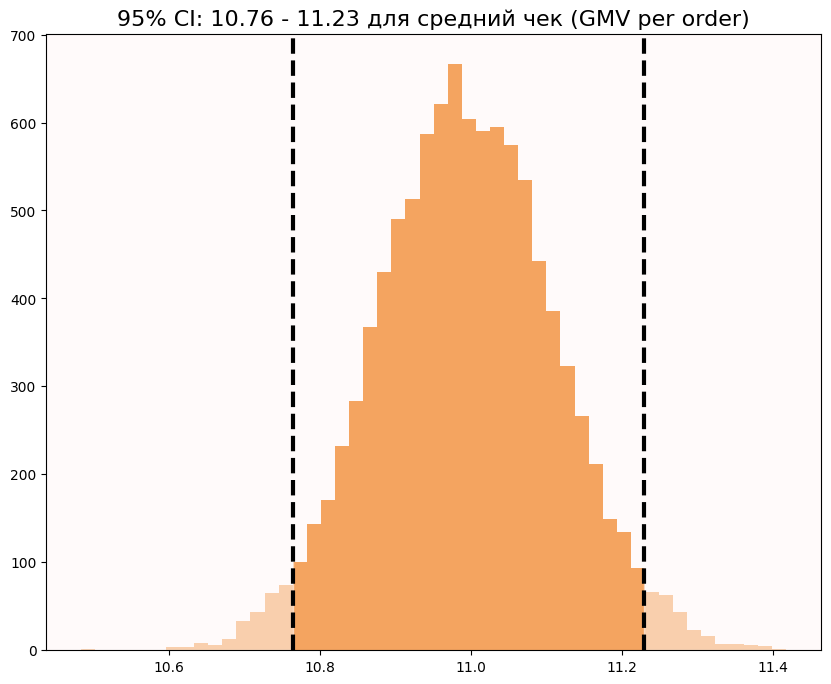

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [67]:
# считаем средние (точечно)

mu_c = df[df['group'] == 'control'].gmv.mean()
mu_t = df[df['group'] == 'test'].gmv.mean()

# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
gvm_class = Bootstrap(df[df['group'] == 'control'].gmv.values, df[df['group'] == 'test'].gmv.values, B = 10000)

gvm_class.get_stats()

gvm_class.CI()

print(gvm_class.pvalue(both = True))

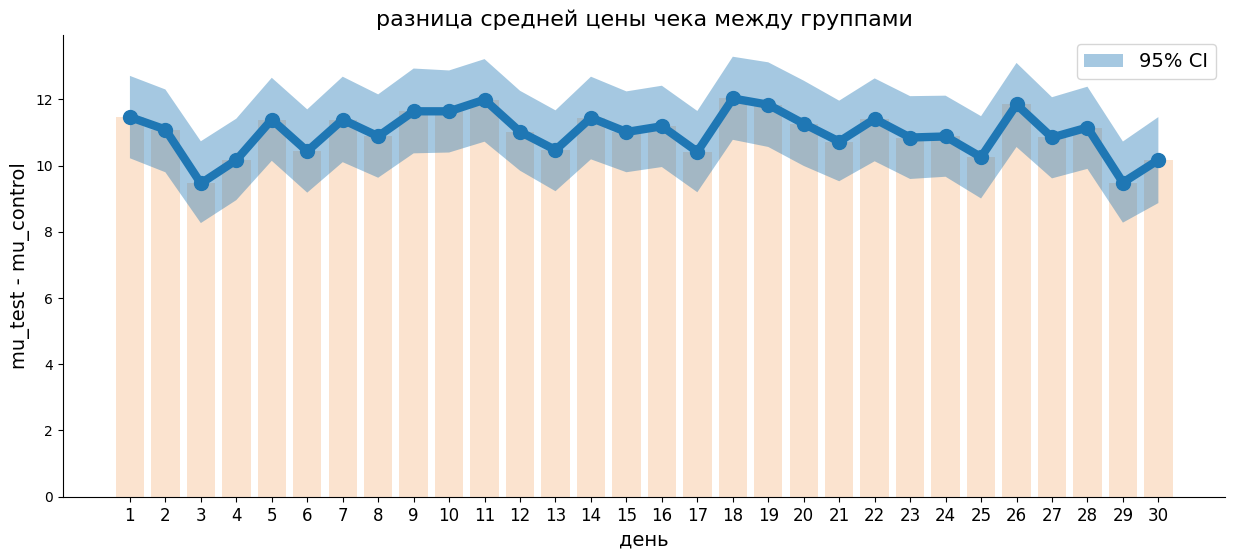

In [112]:
results = []
for day in range(1, 31):
    some_class = Bootstrap(df[(df['day'] == day) & (df['group'] == 'control')].gmv.values, df[(df['day'] == day) & (df['group'] == 'test')].gmv.values, B=5000)
    ci = some_class.CI(print_ci = False)

    results.append({'day': day, 'diff': some_class.mu_t - some_class.mu_c, 'lower': ci[0], 'upper': ci[1]})

results = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(15, 6))

#plt.plot(results['day'], results['diff'], marker='o')
ax.bar(results['day'], results['diff'], alpha = 0.3, color = 'sandybrown')
ax.plot(results['day'], results['diff'], marker='o', linewidth=6, markersize = 10)
ax.fill_between( results['day'], results['lower'], results['upper'], alpha=0.4, label = '95% CI')

plt.xlabel('день', size = 14)
plt.xticks(range(1, 31), range(1, 31), size = 12)
plt.ylabel('mu_test - mu_control', size = 14)
plt.title('разница средней цены чека между группами', size = 16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(fontsize=14)
plt.show()



эффект во времени довольно стабилен. чтобы говорить о тренде нужна какая-либо монотонность, а на графике мы ее не наблюдаем. при эффекте новизны я бы ожидала увидеть сильный пик в первых днях с дальнейшим спадом, на графике же все ровненько. поэтому эффект стабилен

GVM per order (control vs discount): 
    в контрольной группе: 56.015
    в тестовой группе: 67.325

разница средних:
    абсолютная: 11.311
    относительная: 20.19%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале 10.960 and 11.663



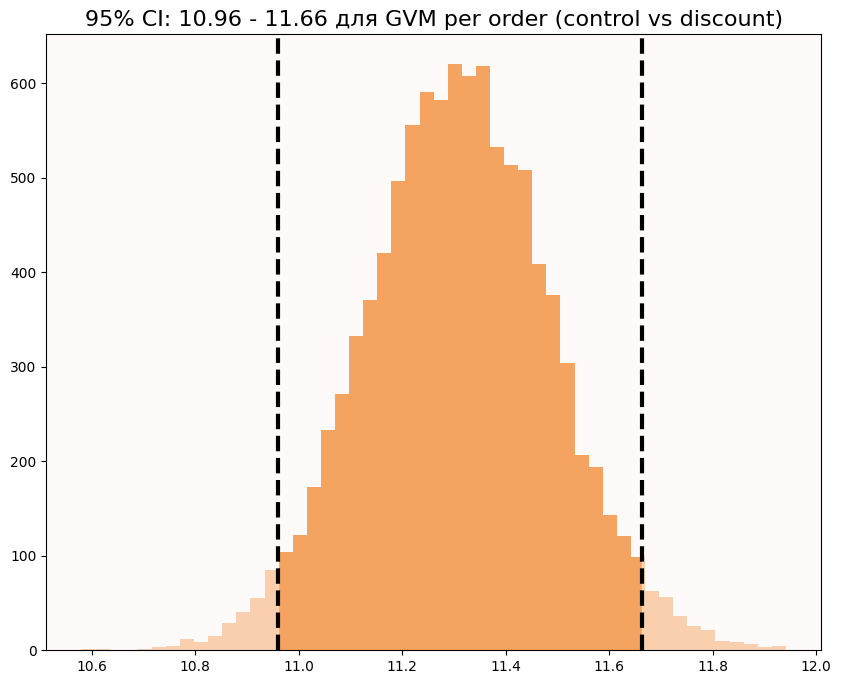

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [205]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
gvm_class = Bootstrap(df[df['group'] == 'control'].gmv.values, df[df['group'] == 'test'][df['promo_applied'] == True].gmv.values, metric_name = 'GVM per order (control vs discount)', B = 10000)

gvm_class.get_stats()

gvm_class.CI()

print(gvm_class.pvalue(both = True))

GVM per order (control vs recommendation only): 
    в контрольной группе: 56.015
    в тестовой группе: 66.871

разница средних:
    абсолютная: 10.856
    относительная: 19.38%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале 10.599 and 11.106



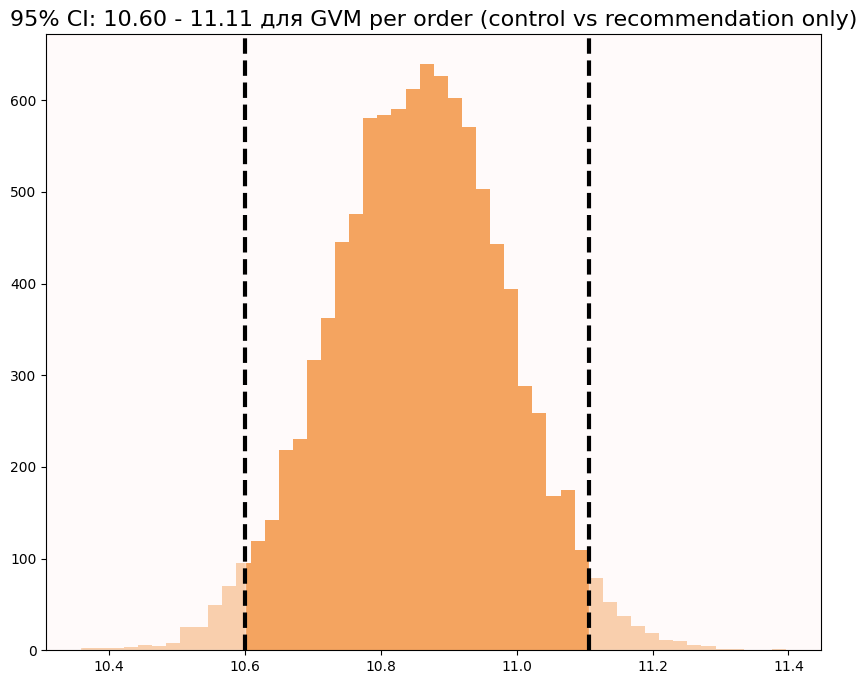

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [206]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
gvm_class = Bootstrap(df[df['group'] == 'control'].gmv.values, df[df['group'] == 'test'][df['promo_applied'] == False].gmv.values, metric_name = 'GVM per order (control vs recommendation only)', B = 10000)

gvm_class.get_stats()

gvm_class.CI()

print(gvm_class.pvalue(both = True))

важно, что средний чек растет не только у пользователей, которые собираются применить промокод к заказу, но и у пользователей, кто не использует промокод. при чем рост в сравнении с контролем наблюдается одинаковый.

##### **защитная метрика (guardrail metric) - средняя маржинальная прибыль**

маржинальная прибыль: 
    в контрольной группе: 14.009
    в тестовой группе: 12.291

разница средних:
    абсолютная: -1.718
    относительная: 12.26%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале -1.780 and -1.656



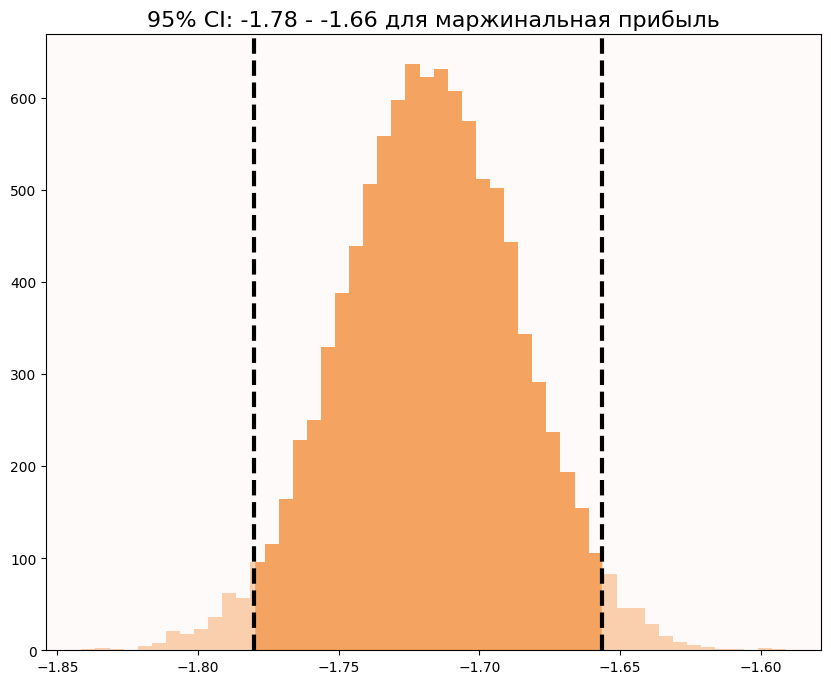

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [111]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
margin_class = Bootstrap(df[df['group'] == 'control'].margin.values, df[df['group'] == 'test'].margin.values, metric_name = 'маржинальная прибыль', B = 10000)

margin_class.get_stats()

margin_class.CI()

print(margin_class.pvalue(both = True))

то есть ничего не выкатываем, так как зищатная метрика падает. но почему?

надо отдельно посмотреть на заказы по промокоду и без (те только с рекоммендацией ресторанов).

сравним control group с заказами из test group with promo и control group с заказами из test group no promo отдельно.

/var/folders/8f/fmfypjj14xqgbh2b31p474tr0000gn/T/ipykernel_16469/569568288.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  margin_class = Bootstrap(df[df['group'] == 'control'].margin.values, df[df['group'] == 'test'][df['promo_applied'] == True].margin.values, metric_name = 'маржинальная прибыль (контроль vs скидка)', B = 10000)


маржинальная прибыль (контроль vs скидка): 
    в контрольной группе: 14.009
    в тестовой группе: 2.000

разница средних:
    абсолютная: -12.009
    относительная: 85.72%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале -12.070 and -11.947



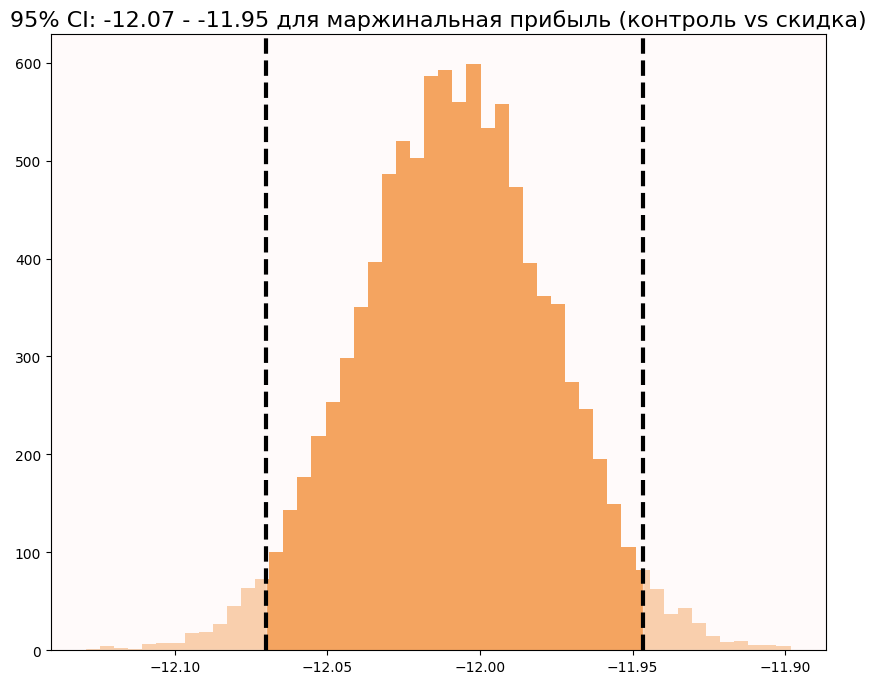

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [138]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
margin_class = Bootstrap(df[df['group'] == 'control'].margin.values, df[df['group'] == 'test'][df['promo_applied'] == True].margin.values, metric_name = 'маржинальная прибыль (контроль vs скидка)', B = 10000)

margin_class.get_stats()

margin_class.CI()

print(margin_class.pvalue(both = True))

маржинальная прибыль (контроль vs без скидки): 
    в контрольной группе: 14.009
    в тестовой группе: 16.707

разница средних:
    абсолютная: 2.698
    относительная: 19.26%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале 2.632 and 2.767



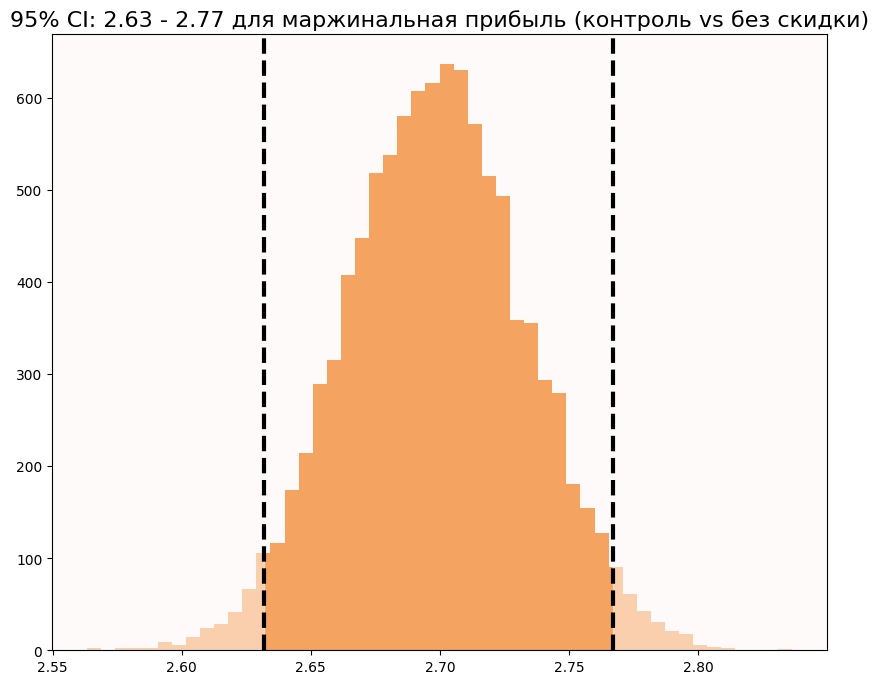

t-test p-value is 0.0000; reject H0
bootstrap p-value is 0.0000; reject H0



In [141]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
margin_class = Bootstrap(df[df['group'] == 'control'].margin.values, df[df['group'] == 'test'][df['promo_applied'] == False].margin.values, metric_name = 'маржинальная прибыль (контроль vs без скидки)', B = 10000)

margin_class.get_stats()

margin_class.CI()

print(margin_class.pvalue(both = True))

какой вывод можно сделать? рекоммендовать рестораны - хорошая идея. а вот промокоды убивают маржу 

##### **дополнительные диагностические метрики**

**количество заказов на пользователя**

количество заказов на человека: 
    в контрольной группе: 7.768
    в тестовой группе: 7.850

разница средних:
    абсолютная: 0.082
    относительная: 1.06%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале -0.002 and 0.165



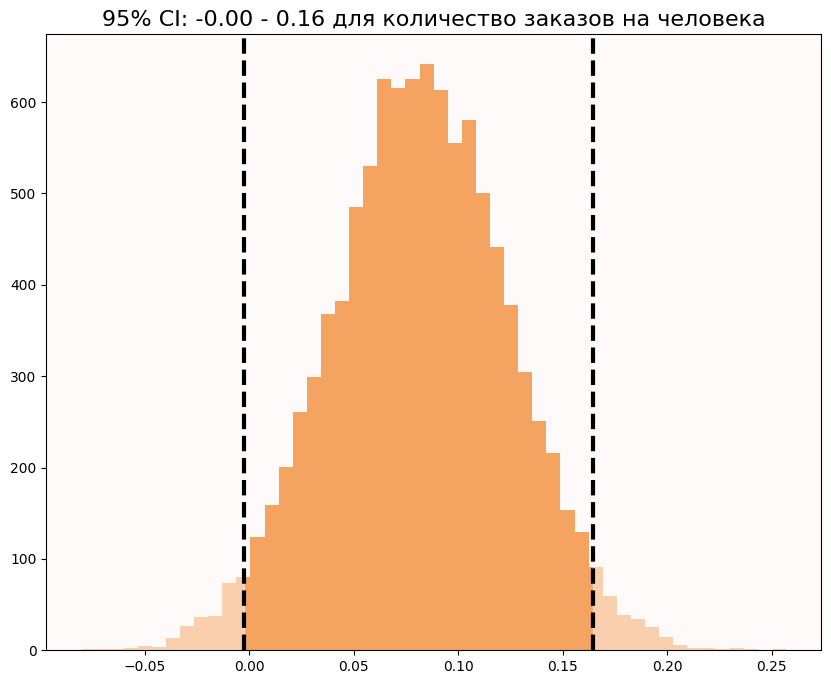

t-test p-value is 0.0508; do not reject H0
bootstrap p-value is 0.0549; do not reject H0



In [116]:
# 95% CI - через bootstrap, воспользуюсь ДЗ 2 №4, только чутка переписала (с пуассона)
some_df = df.groupby(['group', 'user_id']).size().reset_index(name='num_orders')

num_orders_class = Bootstrap(some_df[some_df['group'] == 'control'].num_orders.values, some_df[some_df['group'] == 'test'].num_orders.values, metric_name = 'количество заказов на человека', B = 10000)

num_orders_class.get_stats()

num_orders_class.CI()

print(num_orders_class.pvalue(both = True))

количество заказов на человека не изменилось. то есть увеличение GMV не вызвано более частыми покупками на пользователя

**доля заказов от `new` пользователей**

доля заказов от new users: 
    в контрольной группе: 0.373
    в тестовой группе: 0.365

разница средних:
    абсолютная: -0.008
    относительная: 2.11%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале -0.014 and -0.002



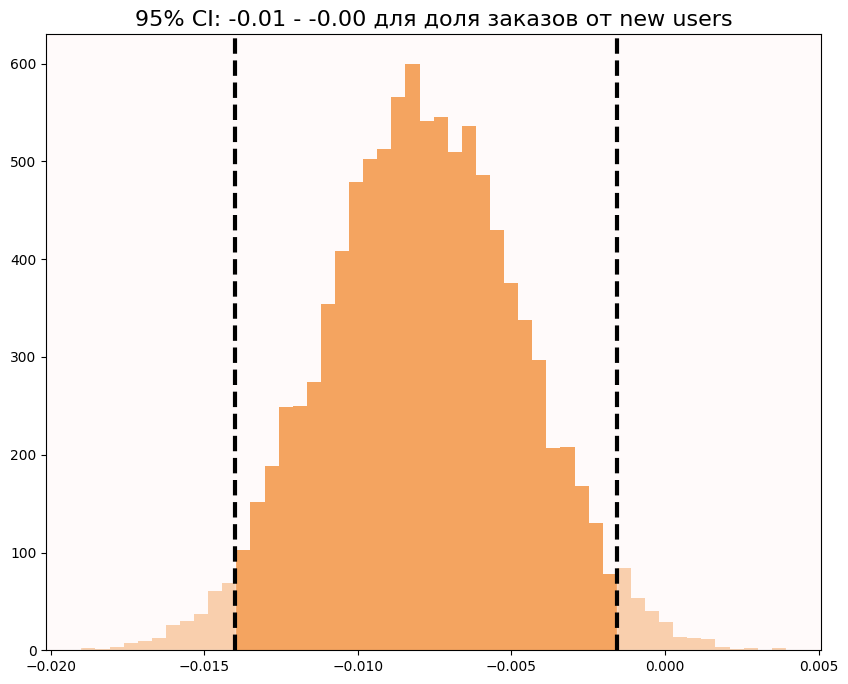

t-test p-value is 0.0122; reject H0
bootstrap p-value is 0.0114; reject H0



In [15]:
some_df = df[['group', 'user_id', 'user_segment']].drop_duplicates()
some_df['user_segment'] = [1 if x == 'new' else 0 for x in some_df['user_segment']]


news_class = Bootstrap(some_df[some_df['group'] == 'control'].user_segment.values, some_df[some_df['group'] == 'test'].user_segment.values, metric_name = 'доля заказов от new users', B = 10000)

news_class.get_stats()

news_class.CI()

print(news_class.pvalue(both = True))


без поправки результат значим: доля заказов от юзеров `new` категории в тестовой группе не равен такой же доли в контроле. По CI можно сказать, что добавление рекоммендаций + промокодов слегка активизировало постояльцев, но не новых пользователей (с другой стороны, персональная рекоммендация может плохо работать для новых пользователей, так как они, возможно, еще не делали заказов, и мы не можем отранжировать рестораны для них)

**длительность пребывания на сайте**

дней от регистрации до активации: 
    в контрольной группе: 260.445
    в тестовой группе: 263.580

разница средних:
    абсолютная: 3.135
    относительная: 1.20%

мы на 95% уверены, что (mu_t - mu_c) находится в интервале 0.218 and 6.147



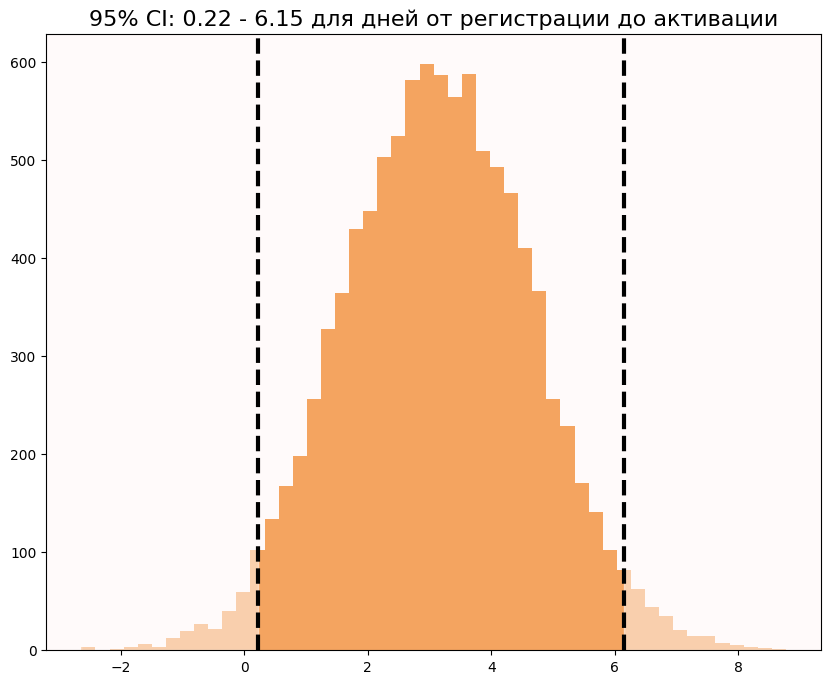

t-test p-value is 0.0364; reject H0
bootstrap p-value is 0.0351; reject H0



In [13]:
# убираем значение 1000, так как это явно тайное знание, не обозначающее 1000 :)
some_df = df[df['tenure_days']!= 1000].groupby(['group', 'user_id']).tenure_days.first().reset_index(name='tenure_days')
margin_class = Bootstrap(some_df[some_df['group'] == 'control'].tenure_days.values, some_df[some_df['group'] == 'test'].tenure_days.values, metric_name = 'дней от регистрации до активации', B = 10000)

margin_class.get_stats()

margin_class.CI()

print(margin_class.pvalue(both = True))

не можем отвергуть H0, но после поправки этот результат, скорее всего, убьется: "время жизни пользователя на сайте" не влияет на средний чек.

##### **multiple test correction**

In [21]:
features = ['количество заказов на человека', 'доля заказов от new пользователей', 'длительность пребывания на сайте']
pvals = [0.0508, 0.0122, 0.0364]
pvals_adj = scipy.stats.false_discovery_control(pvals, method='bh')
reject = [True if pval <= 0.05 else False for pval in pvals_adj]

overall = pd.DataFrame(data = {'feature': features, 'pvalue': pvals, 'pvalue_adj': pvals_adj, 'reject H0': reject})
overall


,feature,pvalue,pvalue_adj,reject H0
0,количество заказов на человека,0.0508,0.0508,False
1,доля заказов от new пользователей,0.0122,0.0366,True
2,длительность пребывания на сайте,0.0364,0.0508,False


## **Часть 3. Сегментный анализ**

напоминение: ***средний чек*** вырос, 95% CI (10.764 - 11.229)

In [89]:
from itertools import combinations

class BootstrapSegment:
    def __init__(self, control, control_segment, test, test_segment, segment_values, metric_name = 'средний чек (GMV per order)', B = 1e4):
        self.control = control
        self.control_segment = control_segment
        self.n_control = len(control)
        self.mu_c = control.mean()
        self.test = test
        self.test_segment = test_segment
        self.n_test = len(test)
        self.mu_t = test.mean()
        self.segment_values = segment_values
        self.B = int(B)
        self.metric_name = metric_name
        self.lower_bound = self.upper_bound = None
        self.percent = None

    def get_stats(self):
        print(f'{self.metric_name}: ')
        print(f'    в контрольной группе: {self.mu_c:.3f}')
        print(f'    в тестовой группе: {self.mu_t:.3f}\n')

        # считаем разницу средних (абсолютная + относительная)
        print(f'разница средних:')
        print(f'    абсолютная: {self.mu_t - self.mu_c:.3f}')
        print(f'    относительная: {abs(self.mu_t - self.mu_c) / self.mu_c * 100:.2f}%\n')


    def CI(self, differences, percent = 0.95, print_ci = False):
        if percent > 1:
            percent = percent / 100
        lower_bound = int(self.B * (1 - percent) / 2)
        upper_bound = int(self.B * (1 - (1 - percent) / 2))

        if print_ci:
            print(f'мы на {int(percent*100)}% уверены, что (mu_t - mu_c) находится в интервале {self.differences[self.lower_bound]:.3f} and {self.differences[self.upper_bound]:.3f}\n')

        return lower_bound, upper_bound


    # в этой функции я использовала чат гпт для рисования скобок на картинке (лень было вспомнить ggplot)
    def get_statistics(self):

        mean_diffs_point = []
        low_CI = []
        upper_CI = []
        diffs_per_value = []

        fig, axes = plt.subplots(1, len(self.segment_values), figsize=(len(self.segment_values)*15, 10))

        for i, value in enumerate(self.segment_values):

            curr_control = self.control[self.control_segment == value]
            curr_test = self.test[self.test_segment == value]

            mean_diffs_point.append(curr_test.mean() - curr_control.mean())

            differences = []

            for _ in range(self.B):
                control_curr_mean = np.random.choice(curr_control, size=len(curr_control), replace=True).mean()
                test_curr_mean = np.random.choice(curr_test, size=len(curr_test), replace=True).mean()
                differences.append(test_curr_mean - control_curr_mean)

            differences = np.array(sorted(differences))
            diffs_per_value.append(differences)
            lower_bound, upper_bound = self.CI(differences)
            low_CI.append(differences[lower_bound])
            upper_CI.append(differences[upper_bound])

            axes[i].set_facecolor('snow')
            axes[i].hist(differences, bins=50, color='sandybrown')
            axes[i].axvline(x=differences[lower_bound], ls='--', lw=3, color='black')
            axes[i].axvline(x=differences[upper_bound], ls='--', lw=3, color='black')
            axes[i].axvspan(differences.min(), differences[lower_bound], color='snow', alpha=0.5)
            axes[i].axvspan(differences[upper_bound], differences.max(), color='snow', alpha=0.5)
            axes[i].set_title(f'{value.upper()} {int(0.95*100)}% CI: {differences[lower_bound]:.2f} - {differences[upper_bound]:.2f}; pvalue = {scipy.stats.ttest_ind(curr_test, curr_control, equal_var=False).pvalue:.4f}', size=16)

        plt.suptitle(self.metric_name, size=36)
        plt.show()

        def add_significance_bracket(ax, x1, x2, y, p_val):
            text = f'p={p_val:.2f}' if p_val >= 0.05 else f'p={p_val:.3f}'
            ax.plot([x1, x1, x2, x2], [y, y + 0.02*y, y + 0.02*y, y], color='black', lw=1.5)
            mid_x = (x1 + x2) / 2
            ax.text(mid_x, 1.025*y, text, ha='center', va='bottom', fontsize=10)

        def compare_segments(segA, segB):
            control_A = self.control[self.control_segment == segA]
            test_A = self.test[self.test_segment == segA]
            control_B = self.control[self.control_segment == segB]
            test_B = self.test[self.test_segment == segB]

            diffs = []
            for _ in range(int(self.B/10)):
                A_c = np.random.choice(control_A, len(control_A), replace=True).mean()
                A_t = np.random.choice(test_A, len(test_A), replace=True).mean()
                B_c = np.random.choice(control_B, len(control_B), replace=True).mean()
                B_t = np.random.choice(test_B, len(test_B), replace=True).mean()
                diffs.append((A_t - A_c) - (B_t - B_c))

            diffs = np.array(diffs)
            ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
            p_val = 2 * min(np.mean(diffs >= 0), np.mean(diffs <= 0))
            return {'diff': np.mean(diffs), 'ci_low': ci_low, 'ci_high': ci_high, 'p_val': p_val}

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.bar(self.segment_values, mean_diffs_point, alpha=0.5, color='sandybrown')
        yerr = np.array([np.array(mean_diffs_point) - np.array(low_CI), np.array(upper_CI) - np.array(mean_diffs_point)])
        ax.errorbar(self.segment_values, mean_diffs_point, yerr=yerr, color='black', capthick=1, capsize=5, fmt='none')
        ax.fill_between(self.segment_values, low_CI, upper_CI, alpha=0.4, label='95% CI')

        combs = list(combinations(range(len(self.segment_values)), 2))
        pvals = []
        for i, j in combs:
            segA = self.segment_values[i]
            segB = self.segment_values[j]
            pvals.append(compare_segments(segA, segB)['p_val'])
        pvals_adj = scipy.stats.false_discovery_control(pvals, method='bh')

        max_y = max(upper_CI) + 0.3 * (len(combs) - 1)
        step = 8 * (max_y - max(upper_CI)) / (len(combs) + 1)

        for idx, (i, j) in enumerate(combs):
            p_adj = pvals_adj[idx]
            y_pos = max_y + idx * step
            add_significance_bracket(ax, i, j, y_pos, p_adj)

        plt.xticks(range(len(self.segment_values)), self.segment_values, size=12)
        plt.ylabel('mu_test - mu_control', size=14)
        plt.title('поиск различий на сегментах ' + self.metric_name, size=16)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.legend(fontsize=14)
        plt.ylim(top = y_pos + 5)
        plt.show()

##### **разрез по `user_segment`**

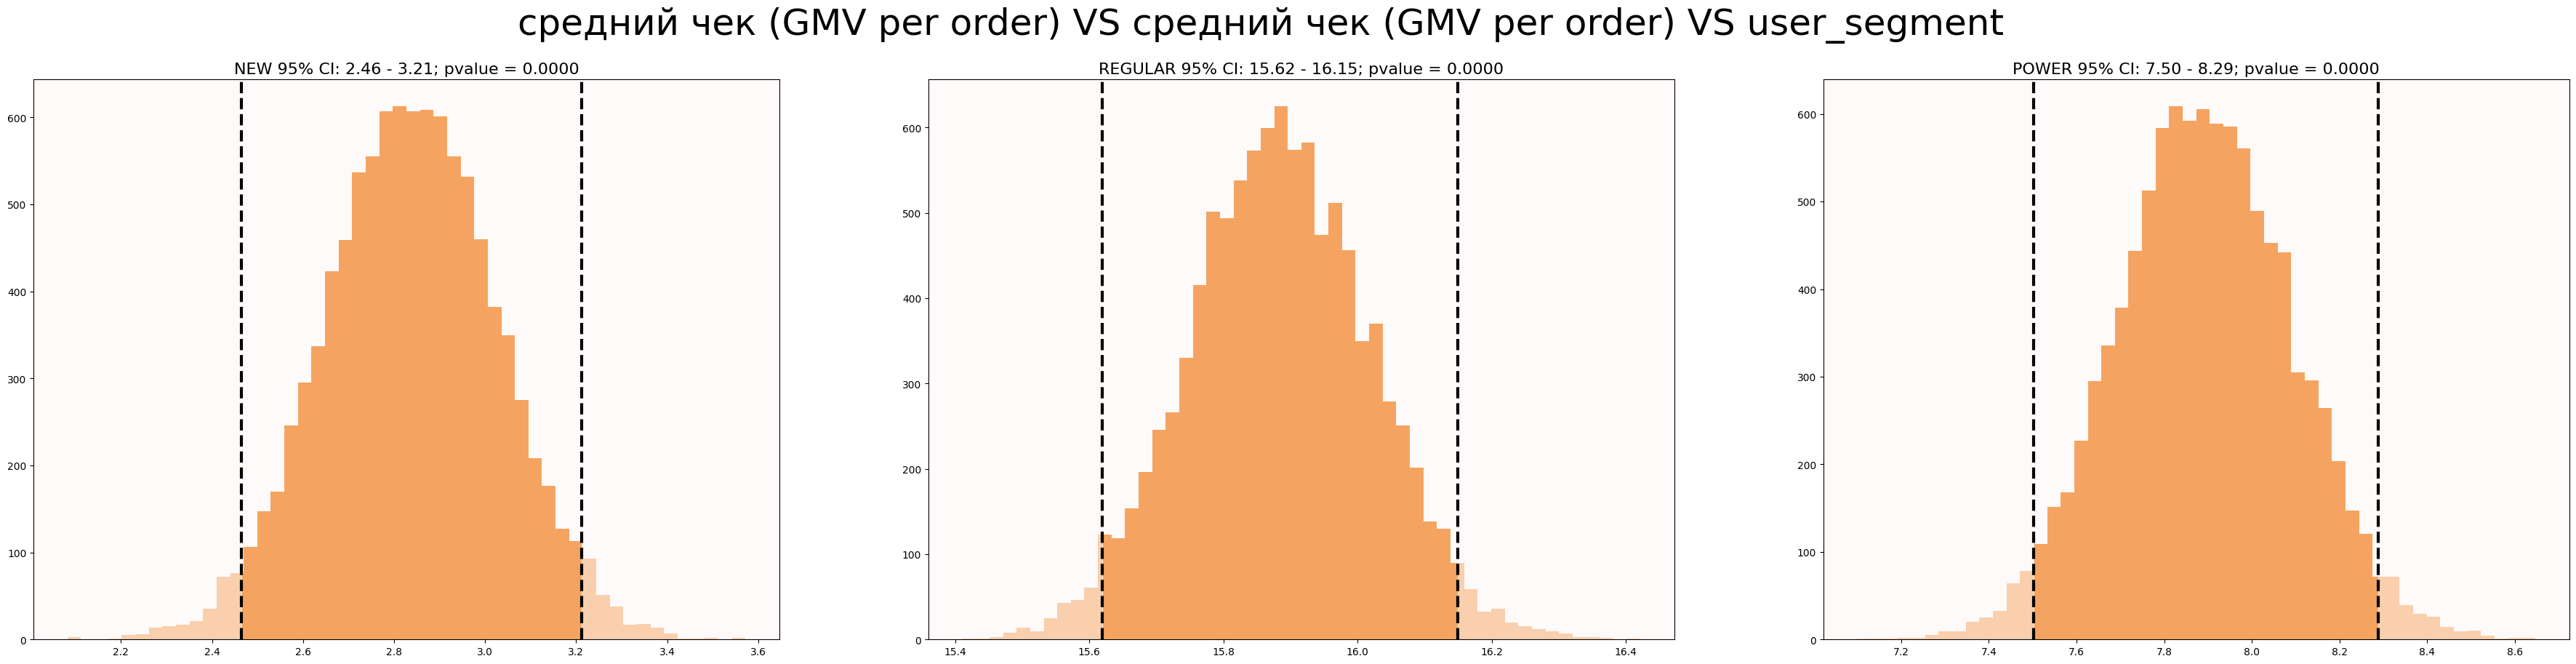

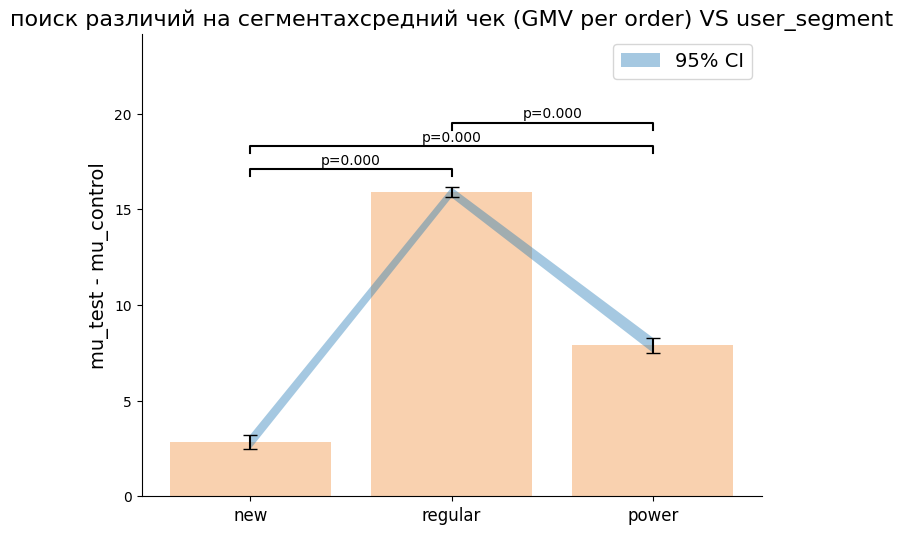

In [62]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.gmv.values, control_group.user_segment.values, test_group.gmv.values, test_group.user_segment.values, df.user_segment.unique(),  metric_name = 'средний чек (GMV per order) VS user_segment', B = 10000)

gvm_class.get_statistics()

Во-первых, видим, что во всех группах средний чек вырос. Но больше всего в группе `regular` пользователей. эффект для `new` юзеров (CI 2.47 - 3.32) мал в сравнении с глобальными трендом (10.764 - 11.229), а для `regular` очень высокий: (15.62 - 16.15). 

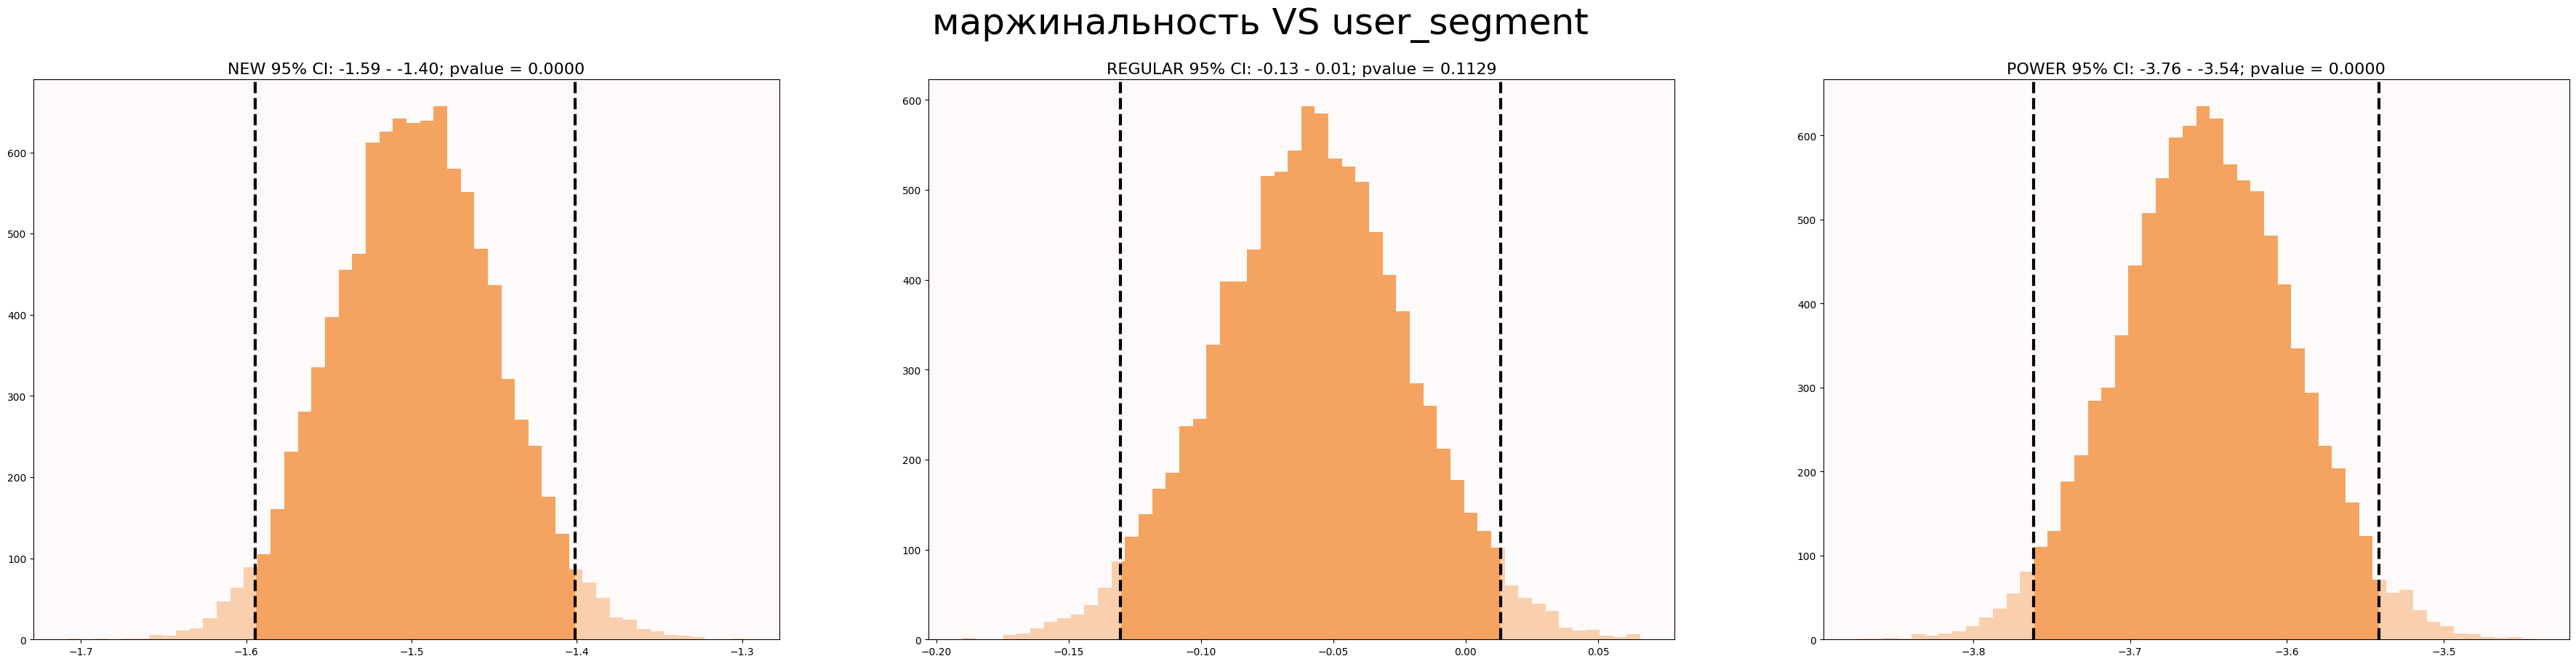

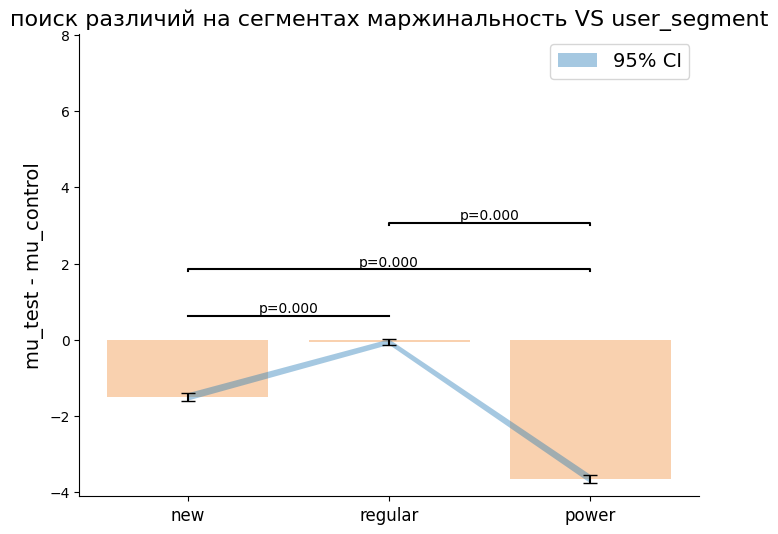

In [65]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.margin.values, control_group.user_segment.values, test_group.margin.values, test_group.user_segment.values, df.user_segment.unique(),  metric_name = 'маржинальность VS user_segment', B = 10000)

gvm_class.get_statistics()

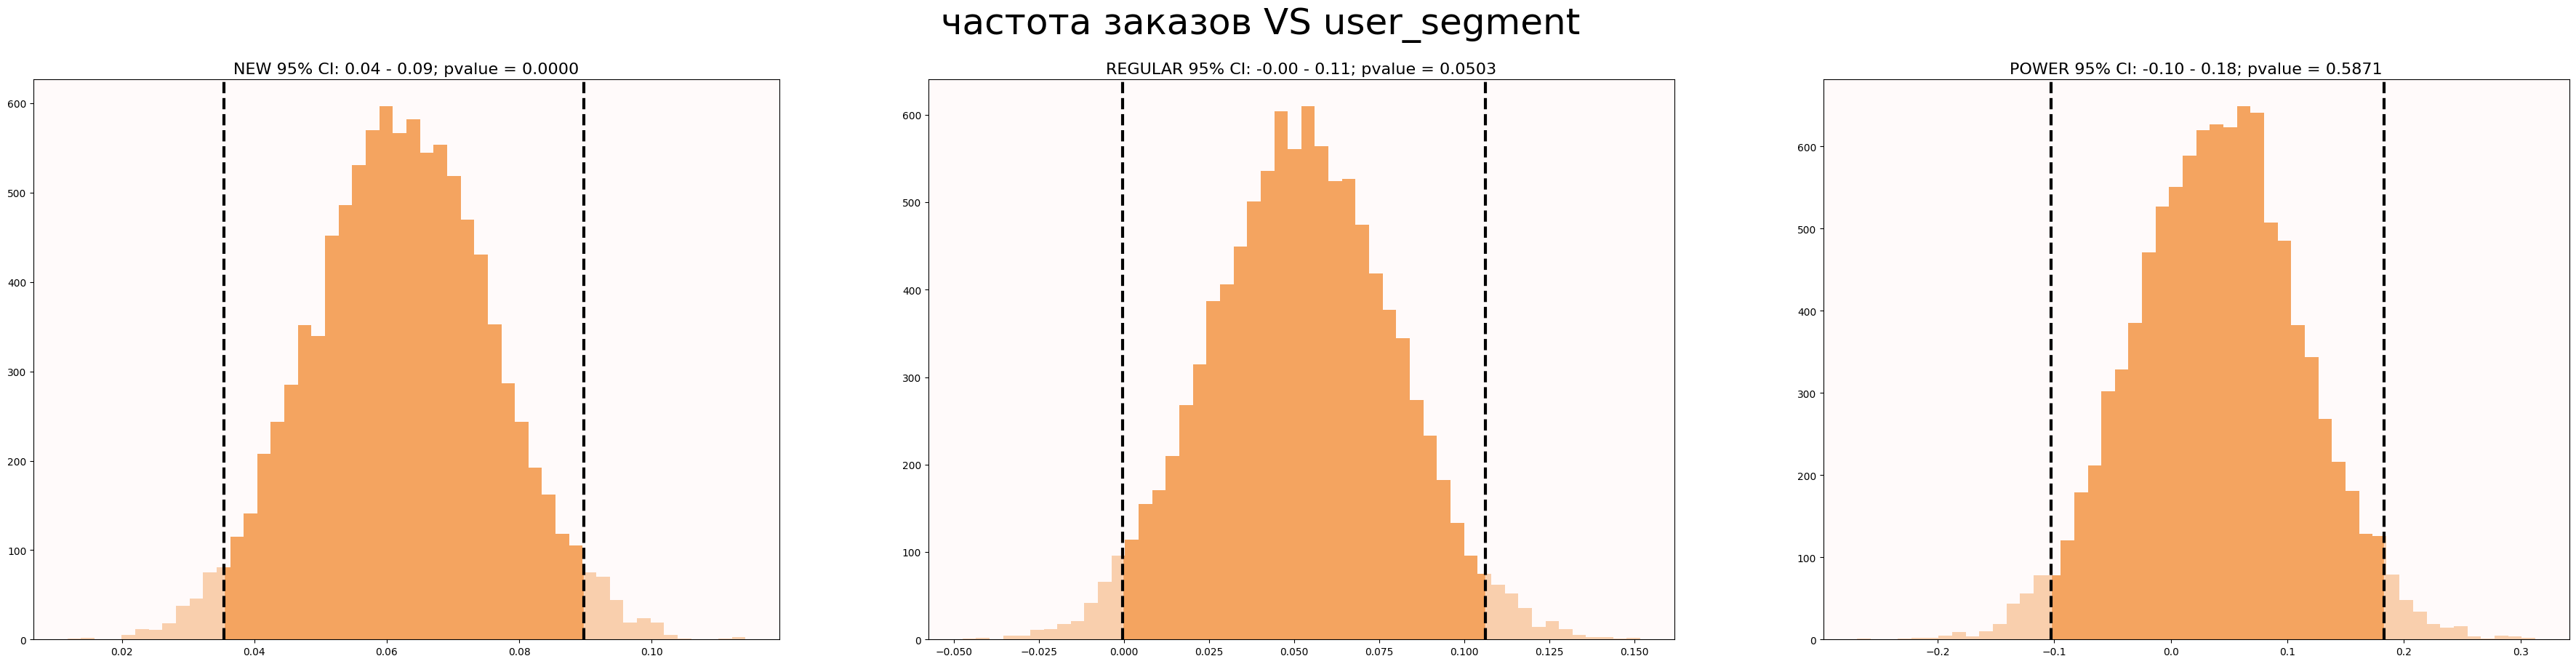

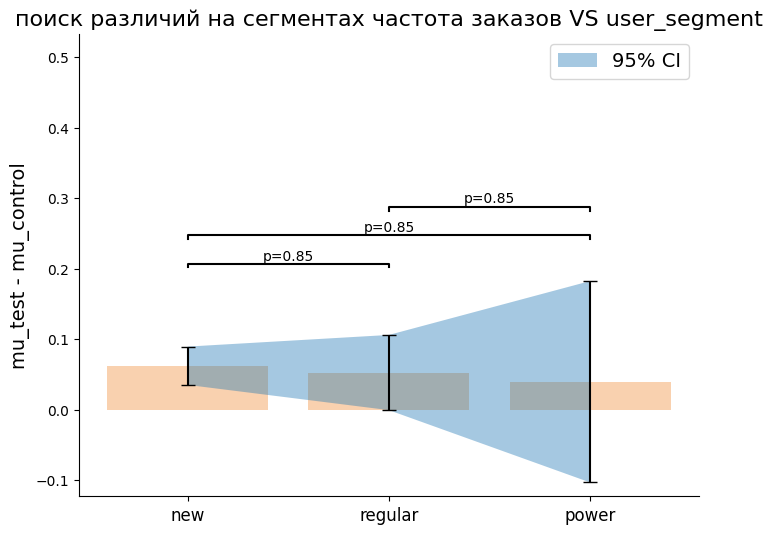

In [74]:
test_group = df[df['group'] == 'test'].groupby(['group', 'user_id', 'user_segment']).size().reset_index(name='num_orders')
control_group = df[df['group'] == 'control'].groupby(['group', 'user_id', 'user_segment']).size().reset_index(name='num_orders')

gvm_class = BootstrapSegment(control_group.num_orders.values, control_group.user_segment.values, test_group.num_orders.values, test_group.user_segment.values, df.user_segment.unique(),  metric_name = 'частота заказов VS user_segment', B = 10000)

gvm_class.get_statistics()

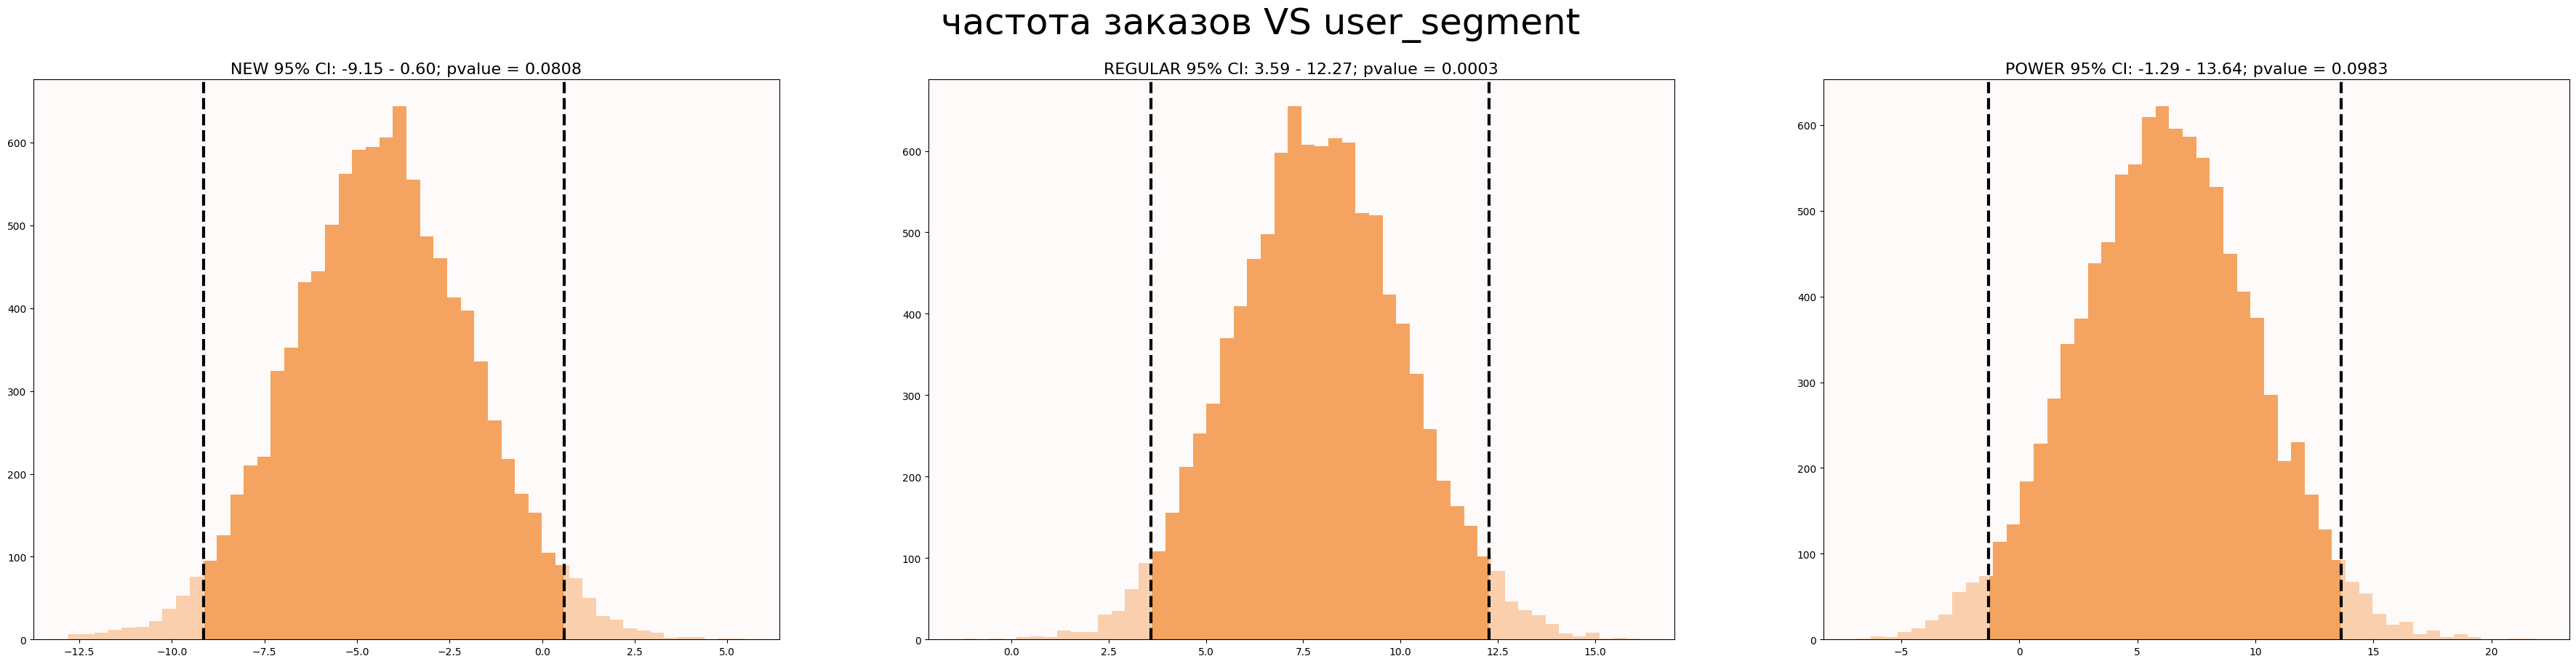

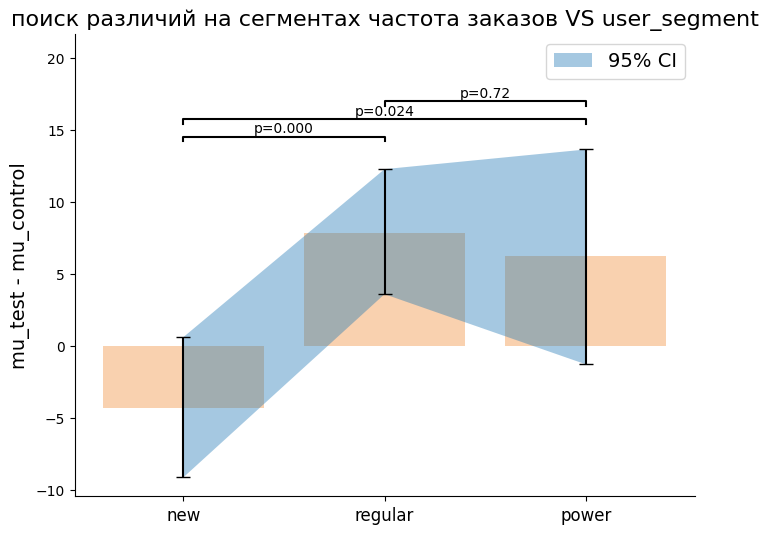

In [ ]:
test_group = df[df['tenure_days']!= 1000][df['group'] == 'test'].groupby(['group', 'user_id', 'user_segment']).tenure_days.first().reset_index(name='tenure_days')
control_group = df[df['tenure_days']!= 1000][df['group'] == 'control'].groupby(['group', 'user_id', 'user_segment']).tenure_days.first().reset_index(name='tenure_days')

gvm_class = BootstrapSegment(control_group.tenure_days.values, control_group.user_segment.values, test_group.tenure_days.values, test_group.user_segment.values, df.user_segment.unique(),  metric_name = 'частота заказов VS user_segment', B = 10000)

gvm_class.get_statistics()


##### **`city`**

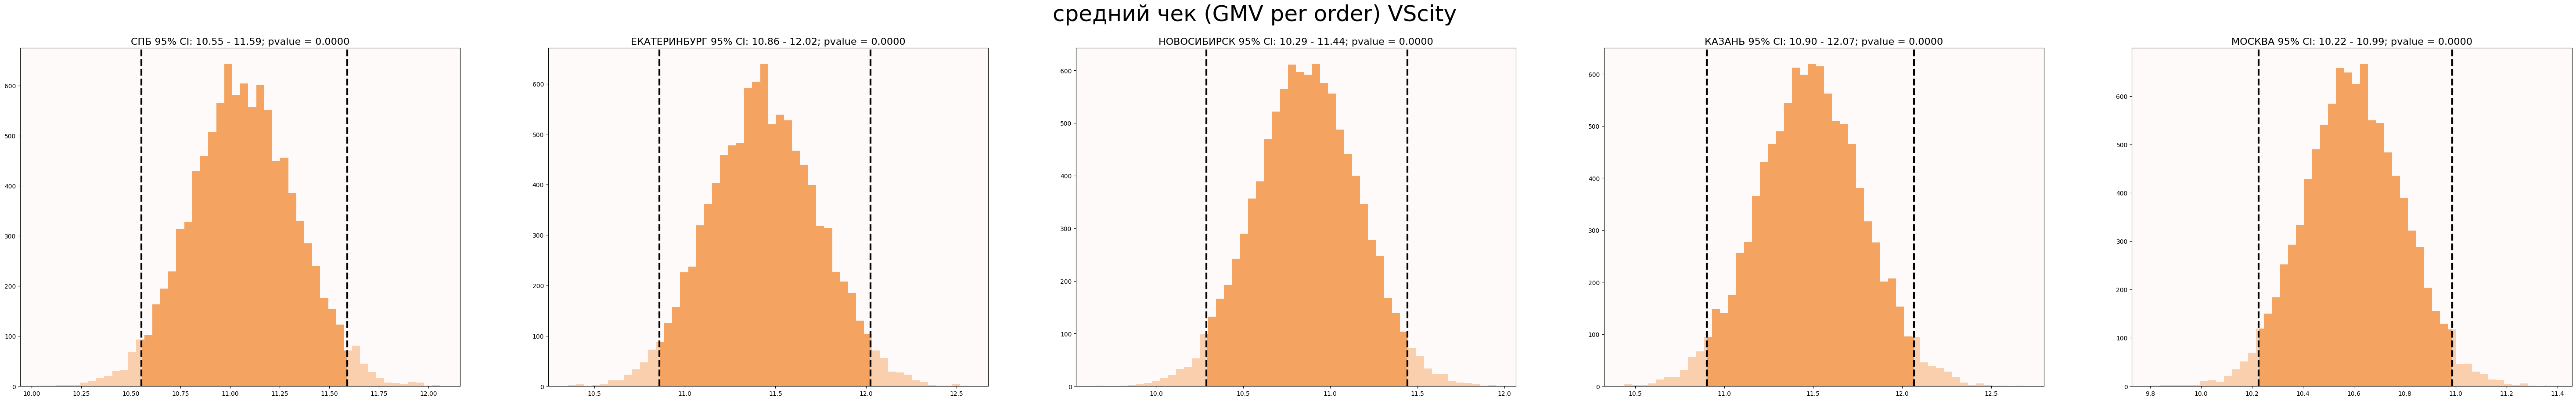

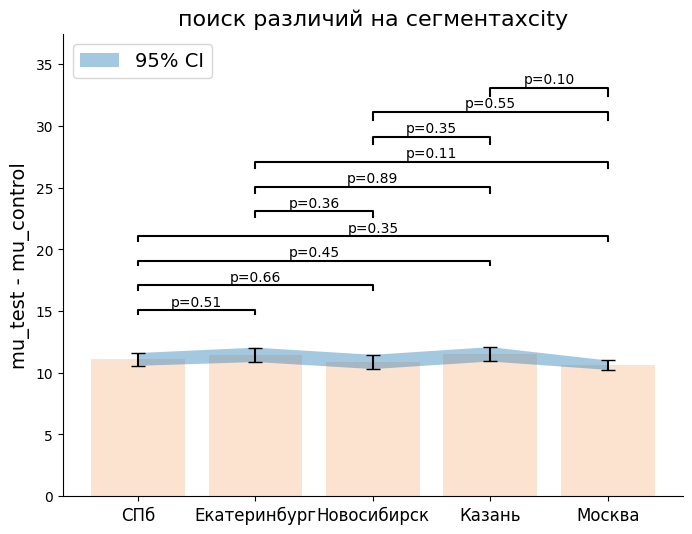

In [ ]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.gmv.values, control_group.city.values, test_group.gmv.values, test_group.city.values, df.city.unique(),  metric_name = 'city', B = 10000)

gvm_class.get_statistics()

нет значимых изменения среднего чека в группах городов. Все эффекты соответствуют глобальному.

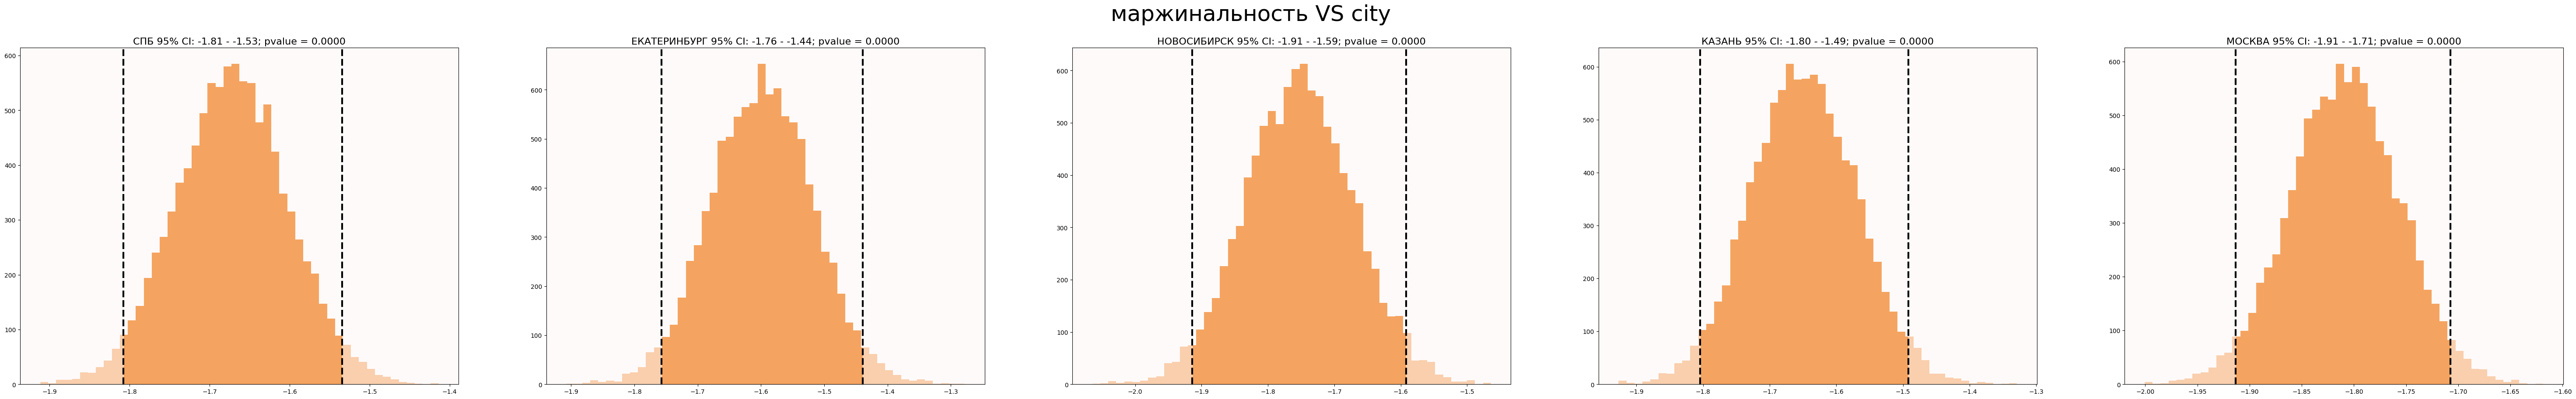

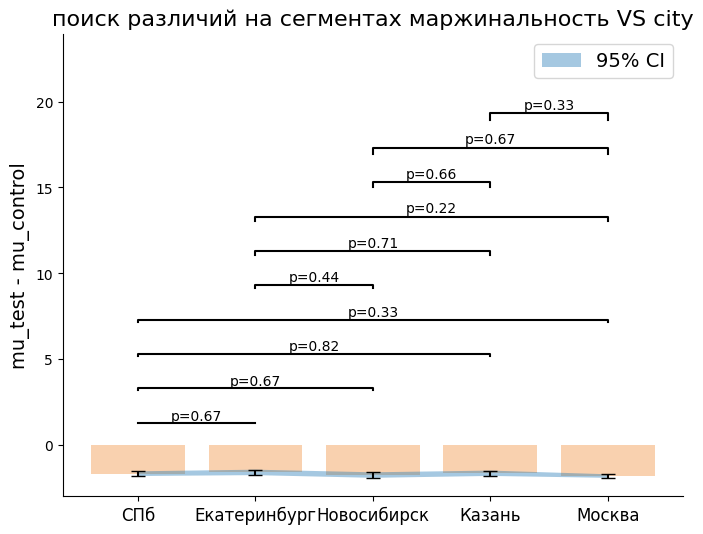

In [83]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.margin.values, control_group.city.values, test_group.margin.values, test_group.city.values, df.city.unique(),  metric_name = 'маржинальность VS city', B = 10000)

gvm_class.get_statistics()

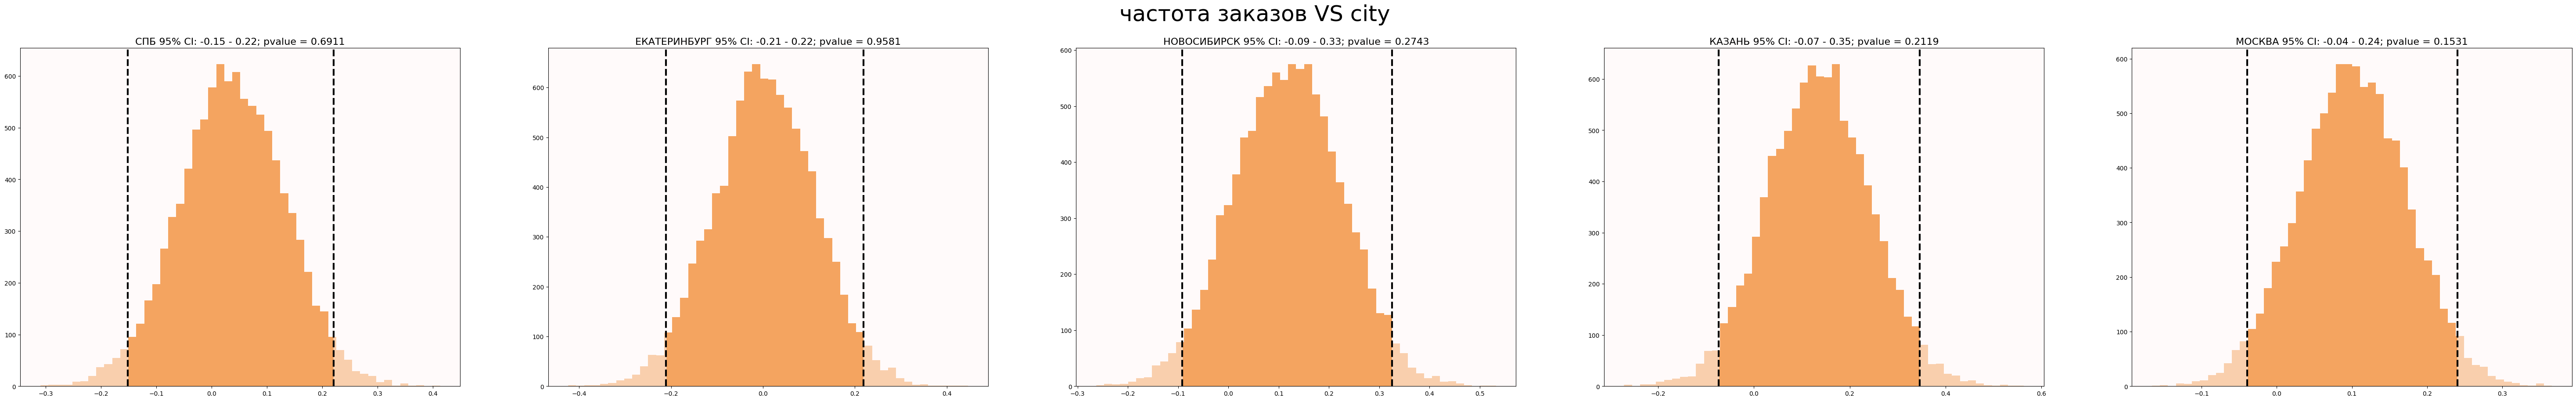

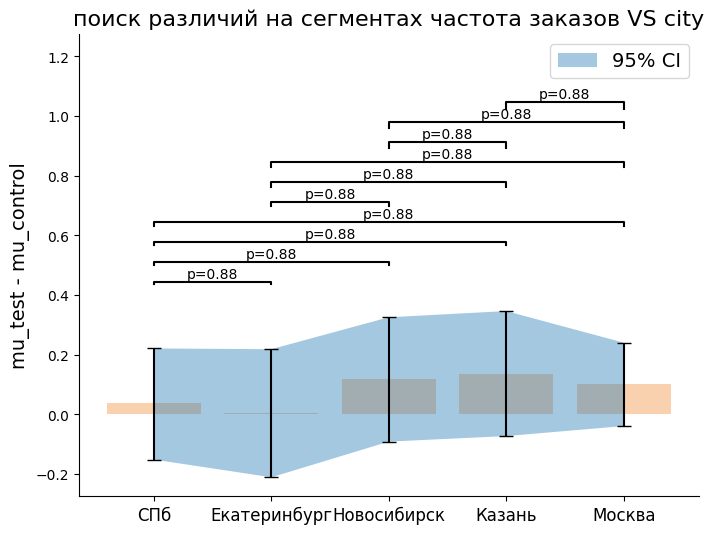

In [87]:
test_group = df[df['group'] == 'test'].groupby(['group', 'user_id', 'city']).size().reset_index(name='num_orders')
control_group = df[df['group'] == 'control'].groupby(['group', 'user_id', 'city']).size().reset_index(name='num_orders')

gvm_class = BootstrapSegment(control_group.num_orders.values, control_group.city.values, test_group.num_orders.values, test_group.city.values, df.city.unique(),  metric_name = 'частота заказов VS city', B = 10000)

gvm_class.get_statistics()

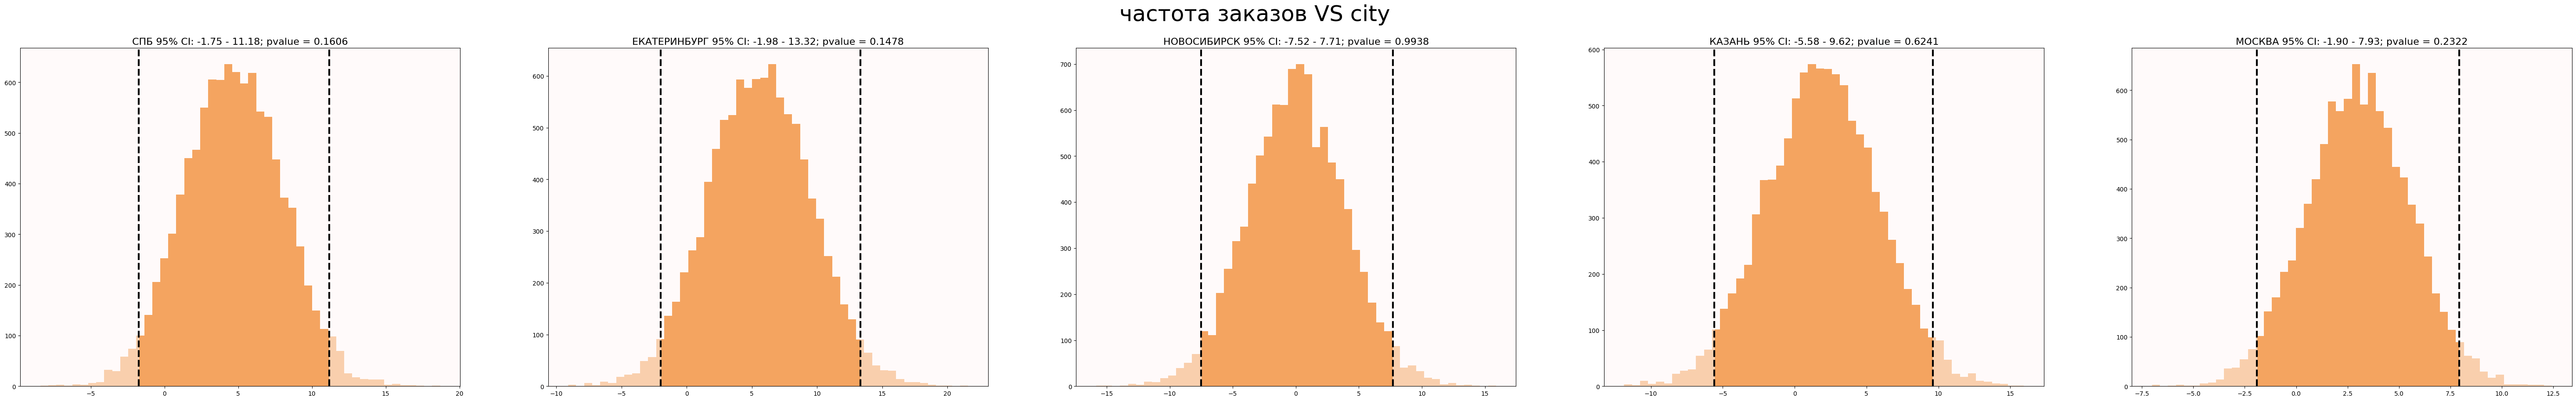

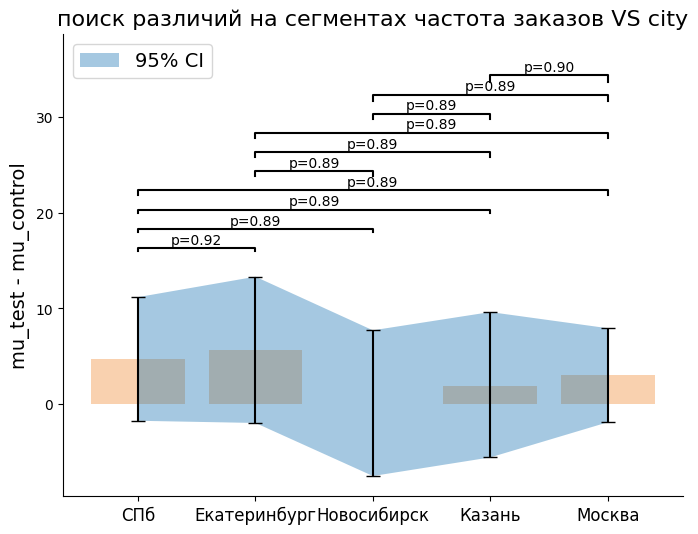

In [84]:
test_group = df[df['tenure_days']!= 1000][df['group'] == 'test'].groupby(['group', 'user_id', 'city']).tenure_days.first().reset_index(name='tenure_days')
control_group = df[df['tenure_days']!= 1000][df['group'] == 'control'].groupby(['group', 'user_id', 'city']).tenure_days.first().reset_index(name='tenure_days')

gvm_class = BootstrapSegment(control_group.tenure_days.values, control_group.city.values, test_group.tenure_days.values, test_group.city.values, df.city.unique(),  metric_name = 'частота заказов VS city', B = 10000)

gvm_class.get_statistics()

##### **`platform`**

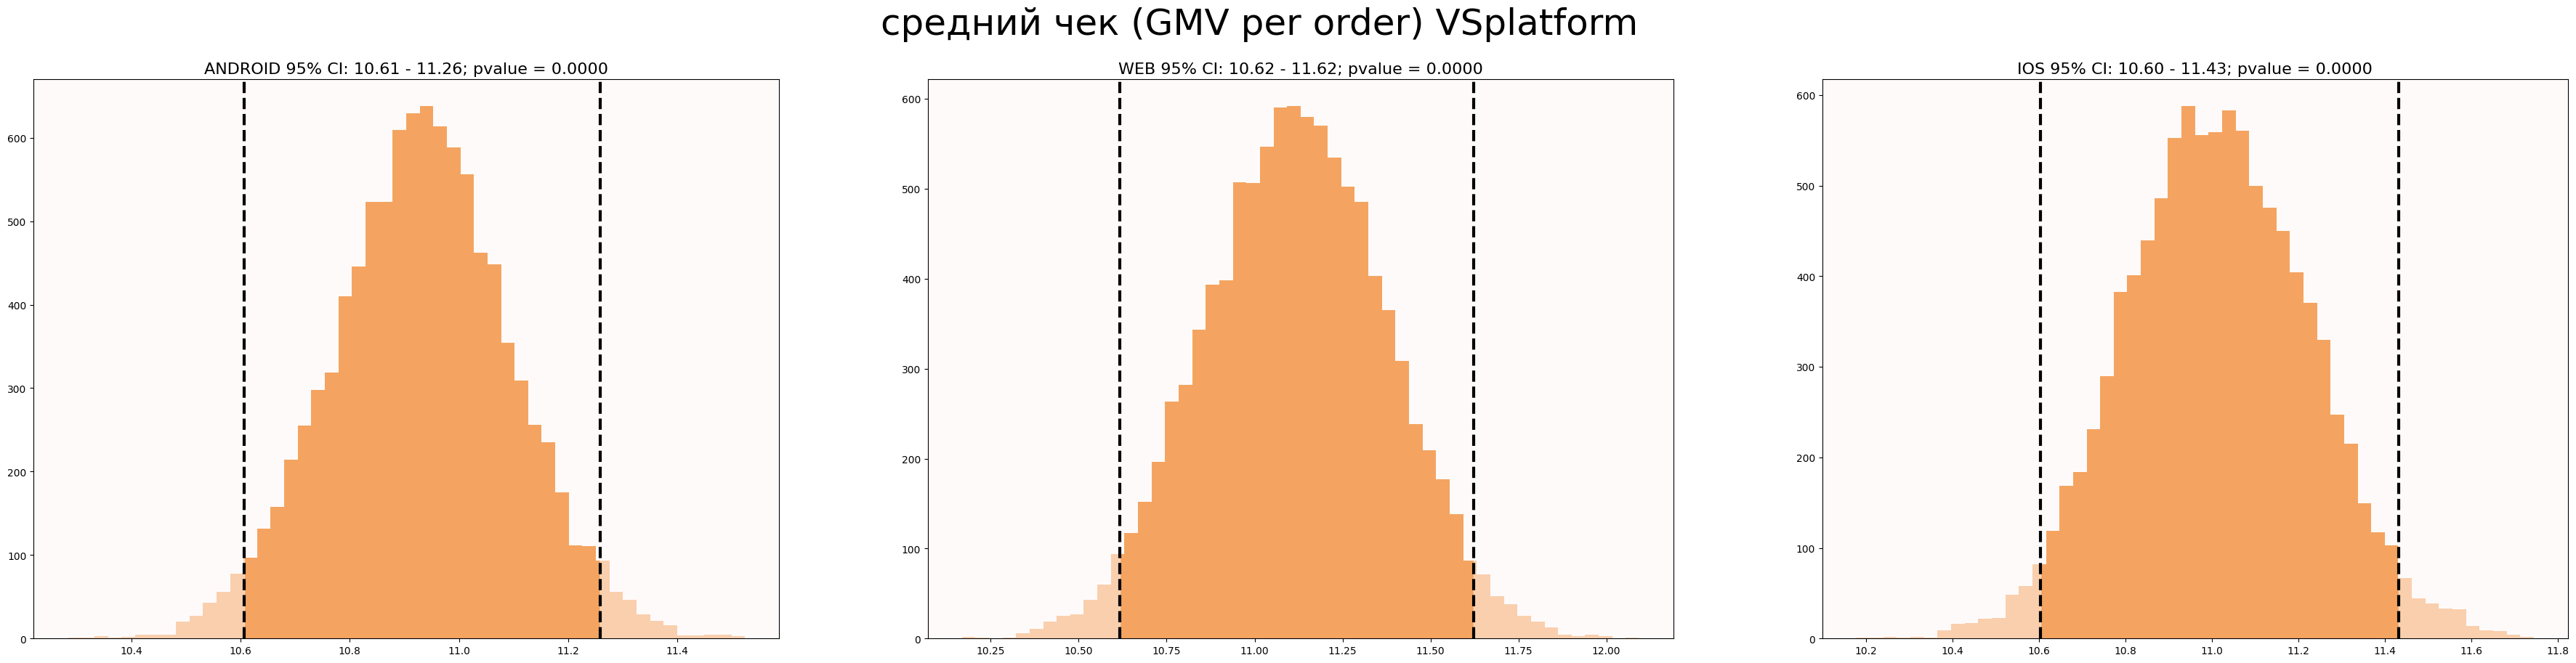

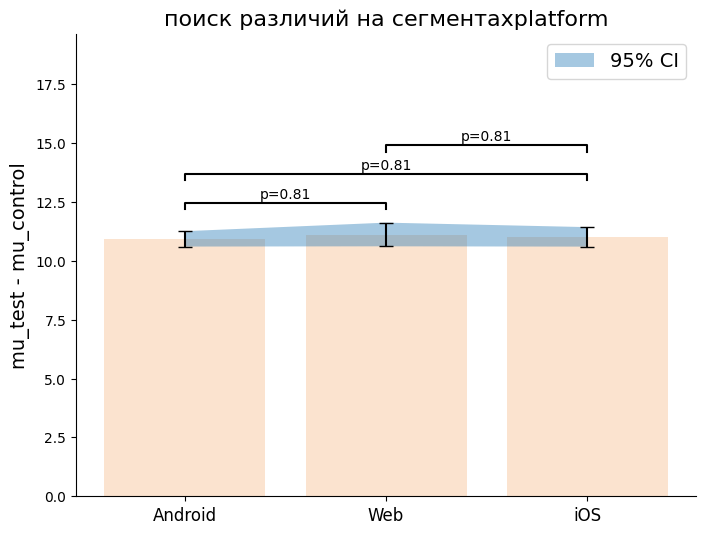

In [ ]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.gmv.values, control_group.platform.values, test_group.gmv.values, test_group.platform.values, df.platform.unique(),  metric_name = 'platform', B = 10000)

gvm_class.get_statistics()

среди платформ мы тоже не наблюдаем различий в группах

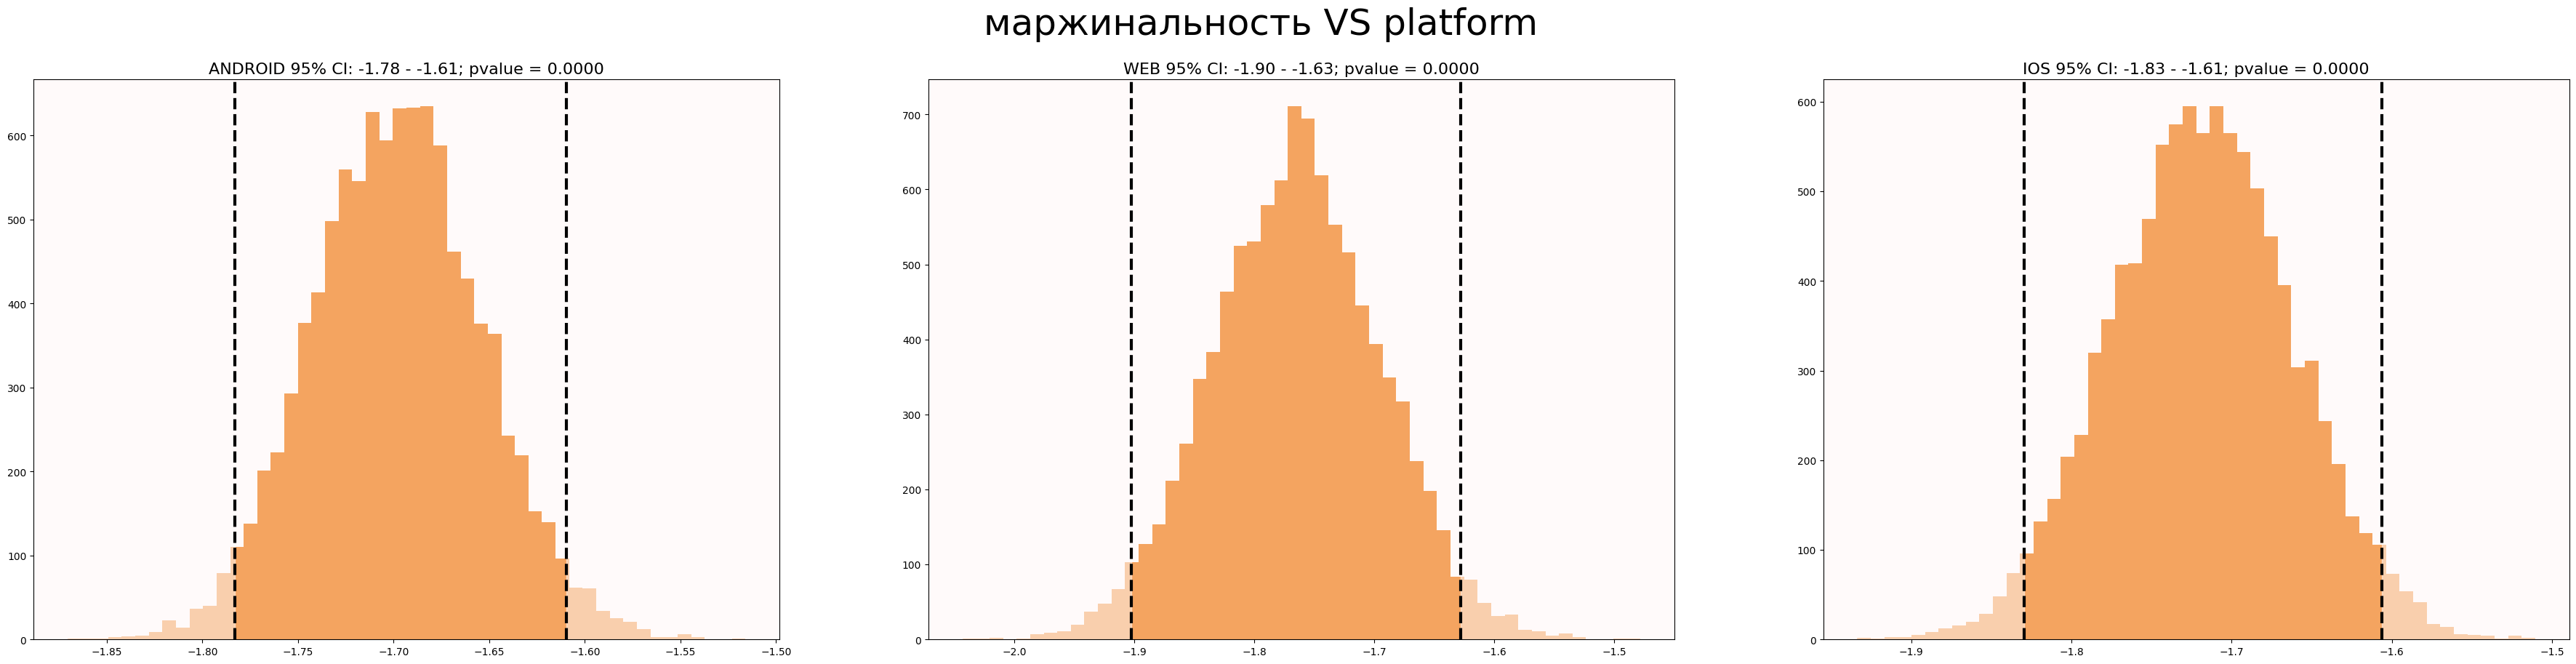

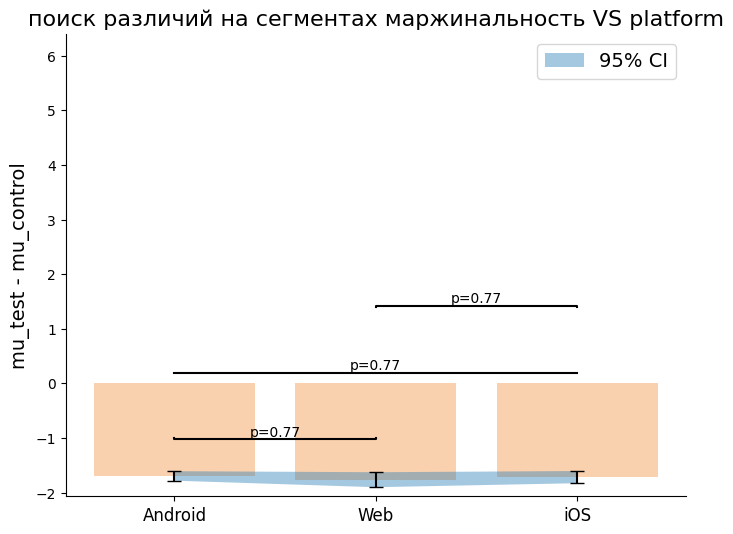

In [90]:
test_group = df[df['group'] == 'test']
control_group = df[df['group'] == 'control']

gvm_class = BootstrapSegment(control_group.margin.values, control_group.platform.values, test_group.margin.values, test_group.platform.values, df.platform.unique(),  metric_name = 'маржинальность VS platform', B = 10000)

gvm_class.get_statistics()

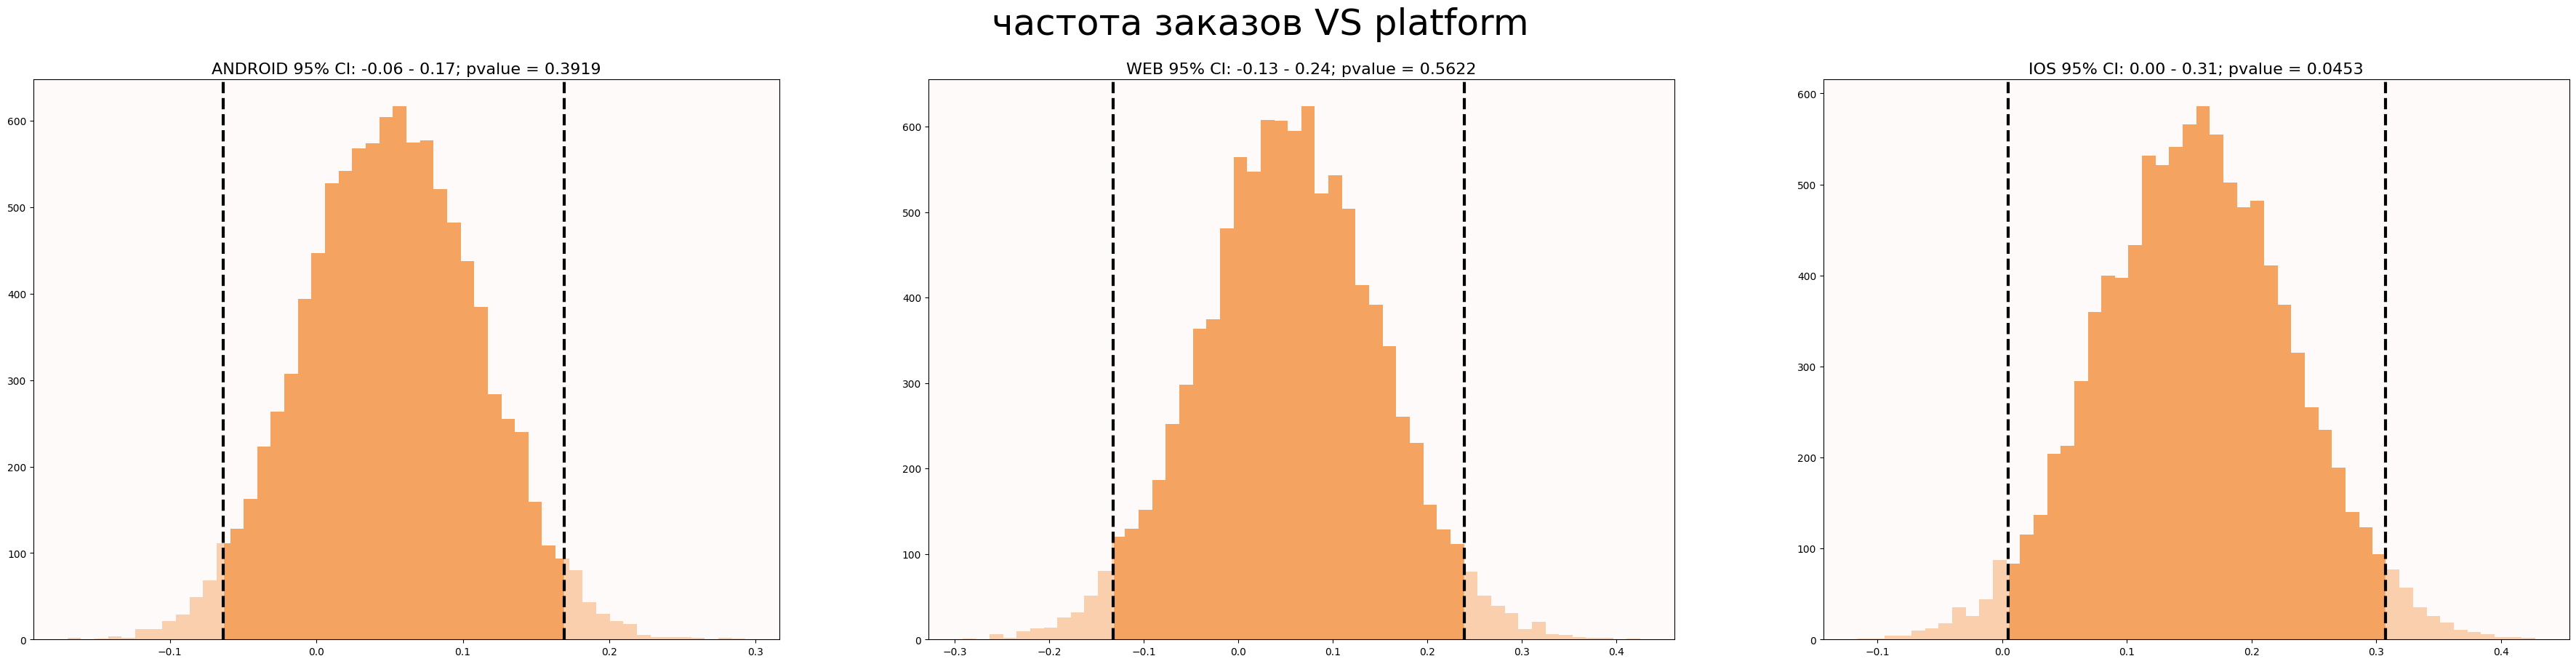

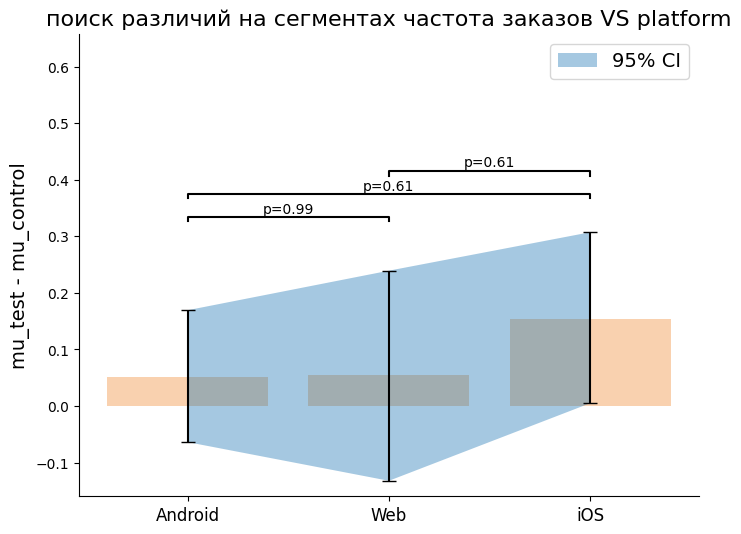

In [88]:
test_group = df[df['group'] == 'test'].groupby(['group', 'user_id', 'platform']).size().reset_index(name='num_orders')
control_group = df[df['group'] == 'control'].groupby(['group', 'user_id', 'platform']).size().reset_index(name='num_orders')

gvm_class = BootstrapSegment(control_group.num_orders.values, control_group.platform.values, test_group.num_orders.values, test_group.platform.values, df.platform.unique(),  metric_name = 'частота заказов VS platform', B = 10000)

gvm_class.get_statistics()

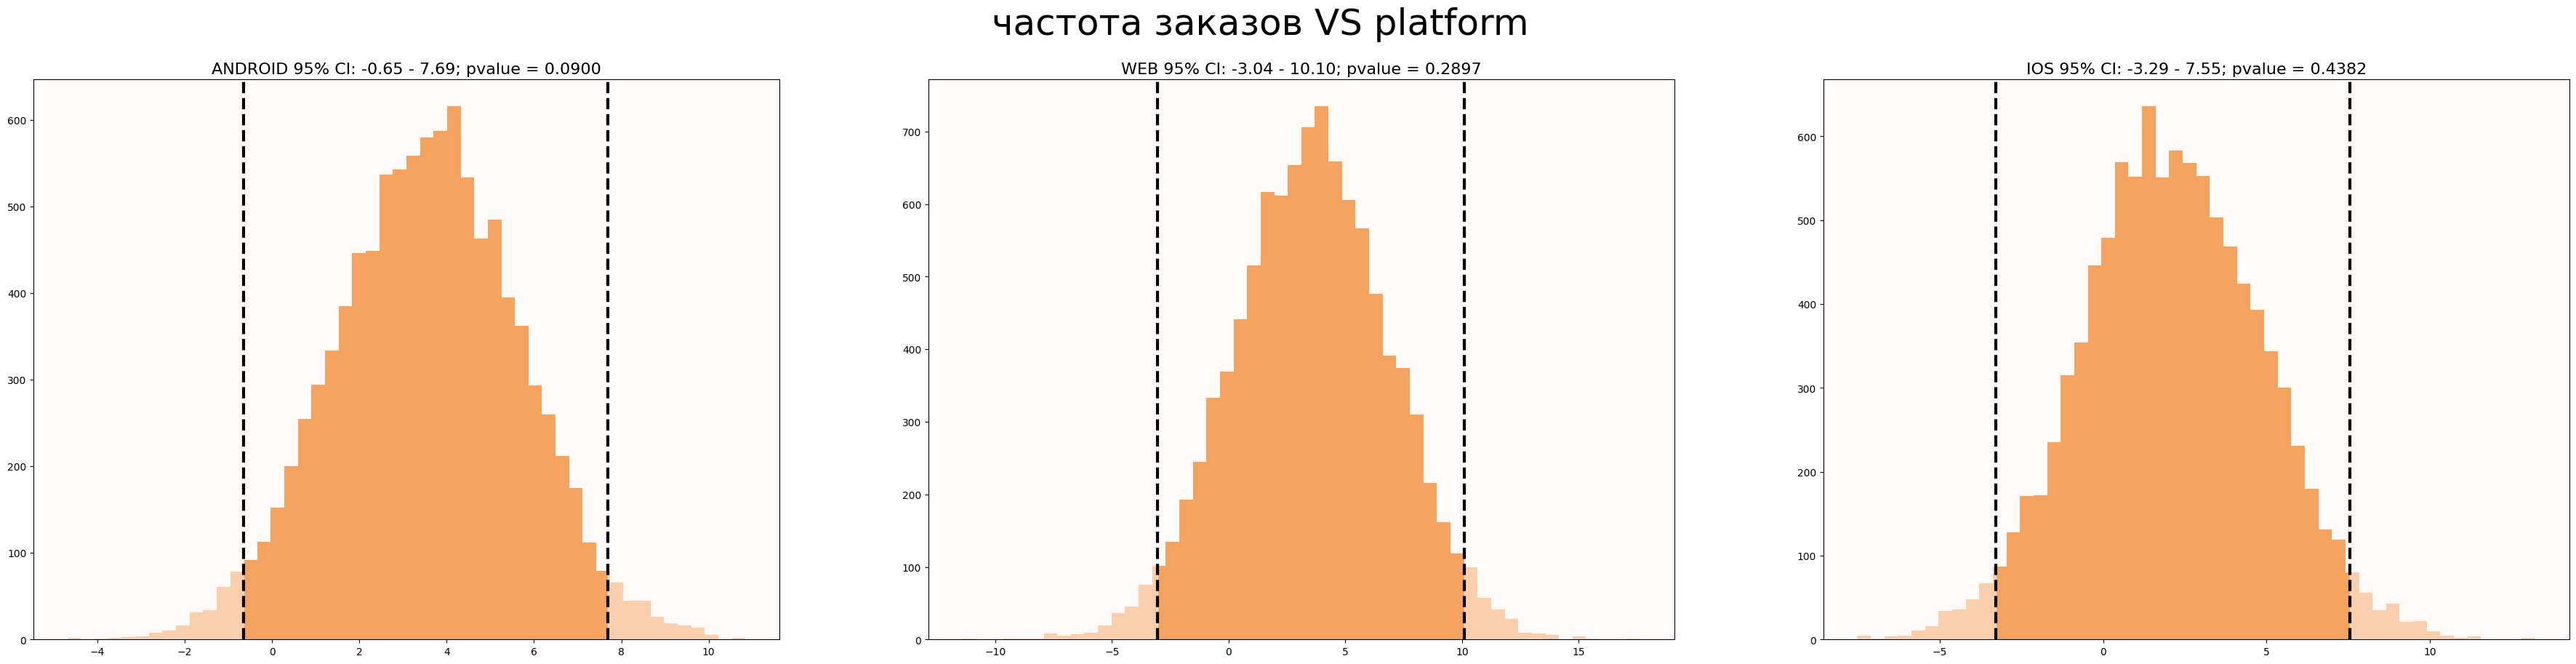

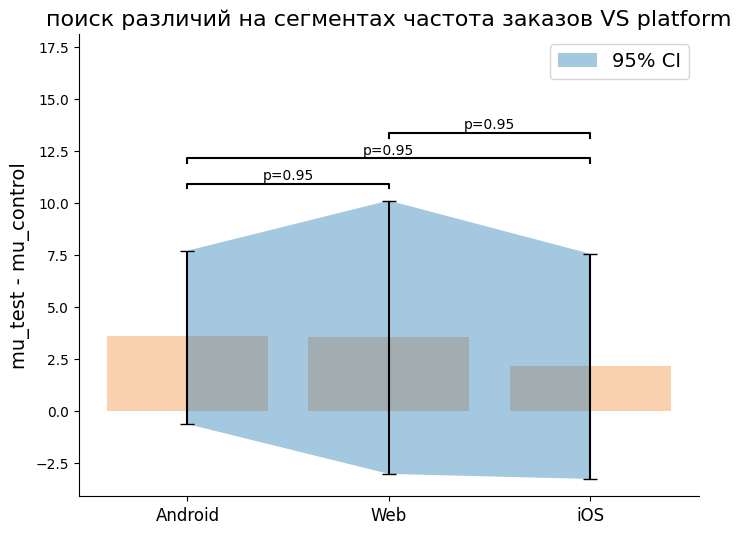

In [91]:
test_group = df[df['tenure_days']!= 1000][df['group'] == 'test'].groupby(['group', 'user_id', 'platform']).tenure_days.first().reset_index(name='tenure_days')
control_group = df[df['tenure_days']!= 1000][df['group'] == 'control'].groupby(['group', 'user_id', 'platform']).tenure_days.first().reset_index(name='tenure_days')

gvm_class = BootstrapSegment(control_group.tenure_days.values, control_group.platform.values, test_group.tenure_days.values, test_group.platform.values, df.platform.unique(),  metric_name = 'частота заказов VS platform', B = 10000)

gvm_class.get_statistics()

## **Часть 4. Бизнес-выводы и рекомендация (выводы)**

**<h4>1. Сработала ли новая механика? Опишите эффект в терминах продукта и денег (не p-value).</h4>**

новая механика сработала и выполнила основуню цель. средний чек заказа в тестовой группе увеличился на 10.993 у.е, что соответствует 19.62% относительного прироста. 
вместе с этим наблюдается значимый падение маржинальной прибыли на заказ на 1.718 у.е. (12.26%). так как 

**<h4>2. Какова структура эффекта? Откуда он берётся: рост среднего чека, рост числа пользователей, что-то ещё?</h4>**

единственное значимое отличие между группами (control vs test) наблюдается в доле `new` пользователей, совершивших заказ. при этом в тестовой группе эта доля меньше. таким образом, новых пользователей не удалось привлечь к заказам с помощью механизма.

при этом не наблюдается значимого отличия между тестовой и контрольной группами для:
-   частоты заказов на пользователя
-   времени регистрации пользователя на сайте
-   рейтинга ресторанов (нет картинки, но проверяла)


**<h4>3. Промокоды: какова их роль? Окупают ли они себя через рост GMV? Как это повлияло на маржинальность?</h4>**

Промокоды в данном механизме не окупают себя через рост GMV, так как маржинальная прибыль упала. При чем важно, что маржинальность заказов без промокода, но с рекоммендацией ресторанов, выросла в сравнении с контролем. При заказы с промокодом снижают маржинальность на 12.009 у.е., что составляет целых 85.72% относительно контроля.

При этом можно сказать, что промокод не влияет на средний чек, так как мы видим одинаковый прирост среднего чека в группе "заказ с промокодом" и "заказ без промокода"

**<h4>4. Выкатываем или нет? Ваша рекомендация с обоснованием:</h4>** 
**• Если выкатываем для всех — почему?**
Нельзя выкатывать на всех пользователей, защитная метрика - маржинальность - упала. При этом падает она именно при использовании промокодов. Кажется, что идея рекоммендации ресторанов при этом отлично себя показывает, средний чек растет при росте маржинальности.

**• Если выкатываем только на отдельные сегменты — на какие и почему?**

не выкатываем! 

**• Если не выкатываем — что нужно учесть при перезапуске?**

очень нужно перезапустить механизм с добавлением только рекоммендаций ресторанов. промокоды полностью съедают маржинальную прибыль, но рекомендательная система (насколько можно судить) работает отлично. 

**<h4>5. Что бы вы сделали иначе при следующем запуске? Какие данные стоило бы собрать дополнительно? Как улучшить дизайн эксперимента?</h4>**

Во-первых, мне кажется, что лента рекоммендаций и промокоды достаточно разнородны по своему эффекту для того, чтобы их проверять в одном A/B тесте на общей тестовой группе. Мы можем попробовать оценить эффект чистых рекоммендаций путем разделения заказов на "с промокодом" и "без промокода", но более честно было бы сделать 3 группы (контроль, тест с рекоммендациями, тест с рекоммендациями и промокодами) или два разных A/B теста.

Во-вторых, по имеющимся данным невозможно понять, были ли достигнуты цели эксперимента. Данные о заказах не содержат информации о неактивных пользователях (одна из целей - повысить долю активных пользователей), также нет информации о заказах до эксперимента (не можем оценить "Привлечь новых пользователей к первому заказу через промокоды"). 

В-третьих, мне не удалось выявить, почему растет средний чек. имеющиеся данные - рейтинг ресторанов - не обязательно коррелирует с ценой блюд в нем (https://medium.com/@jy3340/does-price-point-correlate-with-restaurant-ratings-aa8a12edfc2a). Можно было бы добавить дополнительного описания заказа: количество блюд, средняя цена блюда в ресторане и так далее.

В-четвертых, не хватило описания данных. `user_segment` не очень понятно описывает данные: категория `new` - люди без заказов до старта или с небольшим количеством? также в `tenure_days` есть непонятного происхождения выброс на 1000.

На счет длительности эксперимента не могу ничего сказать, так как не компетентна в вопросе :( 

